In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas as pd
import seaborn as sns
from __future__ import annotations

# from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict

from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin

from tqdm import tqdm
import pickle


# Trying to predict upcoming perturbation disturbance score from neural data

In [14]:
data_dir='/data/bnd-data/raw/'
session='M061_2025_03_06_14_00'

In [15]:
df_ = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
df_ = dsp.preprocess(
    df_,
    only_trials=False,
    combine_time_bins=False, 
    # repair_time_varying_fields=['MotSen1_X', 'MotSen1_Y']
)

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)


In [16]:
df__ = dt.add_pca_df(df_)

In [17]:
ALL_BHV_FIELDS = [
    "left_ankle",
    "left_elbow",
    "left_foot",
    "left_knee",
    "left_paw",
    "left_wrist",
    "right_ankle",
    "right_elbow",
    "right_foot",
    "right_knee",
    "right_paw",
    "right_wrist",
]
feature_dims = np.arange(start=2, stop=len(ALL_BHV_FIELDS)*3, step=3)


In [18]:
df = dt.add_bhv(df__, bhv_fields=ALL_BHV_FIELDS)
df = dt.concat_previous_intertrial_signal(df, 'MOp_rates_pca')
df = dt.concat_previous_intertrial_signal(df, 'SSp_rates_pca')
df = dt.concat_previous_intertrial_signal(df, 'CP_rates_pca')
df = dt.concat_previous_intertrial_signal(df, 'VAL_rates_pca')
df = dt.concat_previous_intertrial_signal(df, 'bhv', features=feature_dims)

# Compute metric
df = dt.add_concat_perturb_time(df)
df = dt.add_concat_trial_start(df)
df = kin.compute_power_in_bhv_concat_td(df)
df = kin.add_power_metric_to_td(df)

# Select trials and drop nans
df = dt.concat_previous_intertrial_signal(df, 'bhv')
df_tr = pyal.select_trials(df, df.trial_name == 'trial')
df_tr = kin.drop_immobile_trials_from_td(df_tr, p=2, win=10)
mask = df_tr["disturb_score"].apply(
    lambda x: not np.any(np.isnan(x))
)
df_tr = df_tr.loc[mask]

# Slice fields
df_tr_sliced = df_tr.copy()
fields = [
    'power',
    'phases', 
    'MOp_rates_pca_concat',
    'SSp_rates_pca_concat',
    'VAL_rates_pca_concat',
    'CP_rates_pca_concat',
    'bhv_concat'
    ]
for field in fields:
    df_tr_sliced[field] = df_tr.apply(
        lambda row: row[field][row["concat_perturb_time"] - 300:row["concat_perturb_time"] + 400, :],
        axis=1
    )

# Add instantaneous phase
df_tr_sliced["perturb_phase"] = df_tr_sliced["phases"].apply(lambda a: a[300, :])

disturbances = np.sum(np.stack(df_tr_sliced.disturb_score.values), axis=1)
dstrb_idx = np.argsort(disturbances)


Skipped 71 trials 10.61
d: 1.194
Bimodal: False
Thresh: 1.09
Dropped 17 of 333 rows (5.11%).


In [186]:
df_design = df_sorted.copy()
df_design = df_design.iloc[:]
df_design['disturb_score'] = df_design['disturb_score'].apply(lambda a: np.log10(np.abs(a)))
df_design_ = df_design.sample(frac=1, random_state=42).reset_index(drop=True)

In [187]:
df_design_.disturb_score.values[0].shape

(12,)

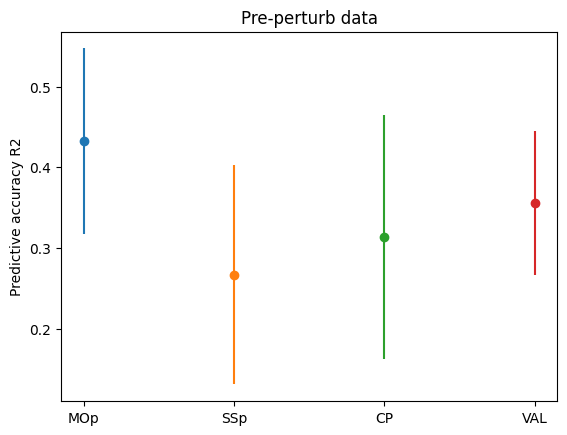

In [10]:
areas = ['MOp', 'SSp', 'CP', 'VAL']
fig, ax = plt.subplots()
for area in areas:
    X = np.stack(df_design_[f'{area}_rates_pca_concat'])[:, 300:, :]
    y = df_design_.disturb_sum.values
    n_trials, n_times, n_comp = X.shape
    

    r2s = cross_val_score(Ridge(alpha=100), X.reshape(-1, n_times * (n_comp)), y, cv=5, scoring=decode.get_custom_scorer())
    ax.errorbar(x=area, y=r2s.mean(), yerr=r2s.std(), fmt='o')
ax.set_ylabel('Predictive accuracy R2')
# ax.set_ylim(0, 0.3)
ax.set_title('Pre-perturb data')
plt.show()

## Try with the null space of m1?

comm_lr = pyal.fit_regressor_model(df, LinearRegression(), f'{from_area}_rates', 'bhv')
comm_subspace = subspaces.get_output_potent_projector(comm_lr)
output_null_subspace = subspaces.get_output_null_projector(comm_lr)
projected_arr = np.array([arr @ output_null_subspace for arr in perturb_td[f'{from_area}_rates'].values])

In [92]:
perturb_td = pyal.restrict_to_interval(df_design_, 'idx_sol_on', rel_start=-200, rel_end=399)
# comm_lr = pyal.fit_regressor_model(perturb_td, LinearRegression(), f'MOp_rates_pca', 'bhv')
# output_null_subspace = subspaces.get_output_null_projector(comm_lr)
# projected_arr = np.array([arr @ output_null_subspace for arr in perturb_td[f'MOp_rates_pca_concat'].values])


In [93]:
perturb_td.columns

Index(['index', 'animal', 'session', 'trial_id', 'trial_name', 'trial_length',
       'bin_size', 'idx_trial_start', 'idx_trial_end', 'idx_CPI',
       ...
       'VAL_rates_pca_concat', 'bhv_concat', 'concat_perturb_time',
       'concat_trial_start', 'power', 'phases', 'disturb_score',
       'perturb_phase', '_row_sum', 'disturb_sum'],
      dtype='object', length=102)

In [120]:
W_mop_ssp_comm = subspaces.compute_embedding(
    perturb_td,
    'VAL_rates_pca',
    'SSp_rates_pca',
    (0, 600),
    subspaces.ReducedRankCommSubspace(rank=50)
)
# comm_lr = pyal.fit_regressor_model(perturb_td, LinearRegression(), f'VAL_rates_pca', 'bhv')
# output_null_subspace = subspaces.get_output_null_projector(comm_lr)

projected_arr = np.array([arr @ W_mop_ssp_comm for arr in df_design_[f'VAL_rates_pca'+'_concat'].values])


In [121]:
W_mop_ssp_comm.shape

(168, 50)

In [109]:
projected_arr = np.array([arr for arr in df_design_[f'MOp_rates_pca'+'_concat'].values])
projected_arr.shape


(257, 700, 178)

In [110]:
X = projected_arr[:, :, :]
# X = np.stack(df_design_.MOp_rates_pca.values)
y = df_design_.disturb_sum.values
n_trials, n_times, n_comp = X.shape
r2s = cross_val_score(Ridge(alpha=100), X.reshape(-1, n_times * (n_comp)), y, cv=5, 
                      # scoring=decode.get_custom_scorer()
                      )
print(f'r2 mean: {r2s.mean():.4f}, r2 std: {r2s.std():.4f}')

r2 mean: 0.4005, r2 std: 0.0851


## Attempt to create a disturbance axis
The idea would then be that, activity along that axis, fitted on many trials, carries information on the effect of the upcoming trials

In [127]:
X.reshape(n_trials * n_times,-1).shape
y_repeated = np.tile(y, 200)
y_repeated.shape

(51400,)

In [200]:
y_repeated.shape

(51400, 12)

In [243]:
model = Ridge(alpha=100)
X = np.stack(df_design_.MOp_rates_pca_concat.values)[:, 300:, :]
n_trials, n_times, n_comp = X.shape

y = np.stack(df_design_.disturb_score.values)
y_repeated = np.tile(y, (400, 1))  # Shape will be (257 * 200, 12)

# r2s = cross_val_score(Ridge(alpha=100), X.reshape(n_trials * n_times,-1), y_repeated, cv=5, 
#                       scoring=decode.get_custom_scorer()
#                       )
r2s = cross_val_score(Ridge(alpha=100), X.reshape(-1, n_times * n_comp), y, cv=5, 
                      scoring=decode.get_custom_scorer()
                      )
print(f'r2 mean: {r2s.mean():.4f}, r2 std: {r2s.std():.4f}')

model.fit(X.reshape(-1, n_times * n_comp), y)
W = np.expand_dims(model.coef_.T, axis=-1)
W = W.reshape(n_times, n_comp, 12)
w = np.sqrt(np.sum(W**2, axis=0))
# w_norm = w / np.linalg.norm(w)

projected_arr = np.array([arr[:, :] @ w for arr in df_design_[f'MOp_rates_pca'+'_concat'].values])[:, :]
r2s = cross_val_score(Ridge(alpha=100), projected_arr.reshape(-1, 700 * 12), y, cv=5, 
                      scoring=decode.get_custom_scorer()
                      )
print(f'r2 mean: {r2s.mean():.4f}, r2 std: {r2s.std():.4f}')


r2 mean: 0.3509, r2 std: 0.0403
r2 mean: 0.0675, r2 std: 0.0211


In [219]:
W.shape

(400, 50, 12)

In [221]:
w.shape

(50, 12)

In [240]:
projected_arr.shape

(257, 700, 12)

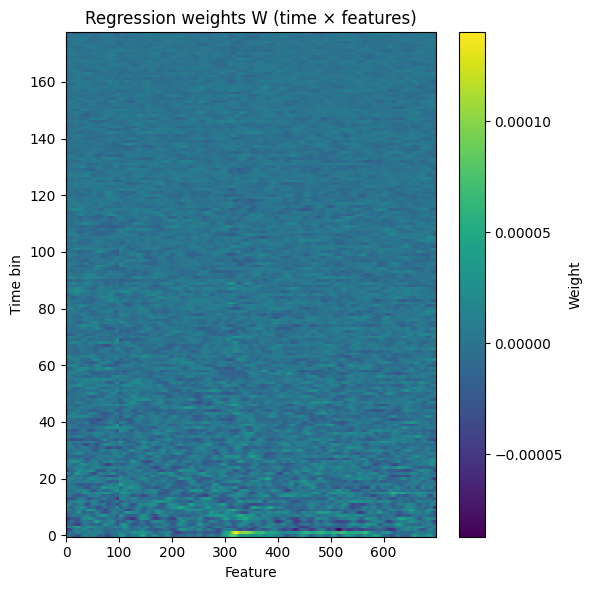

In [118]:
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(W.T, aspect="auto", origin="lower", interpolation="nearest")
ax.set_xlabel("Feature")
ax.set_ylabel("Time bin")
ax.set_title("Regression weights W (time × features)")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Weight")

plt.tight_layout()
plt.show()

# Clean plots of disturbance metric

In [4]:
data_dir='/data/bnd-data/raw/'
session='M061_2025_03_06_14_00'

In [5]:
df_ = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
df_ = dsp.preprocess(
    df_,
    only_trials=False,
    combine_time_bins=False, 
    # repair_time_varying_fields=['MotSen1_X', 'MotSen1_Y']
)

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)


In [6]:
df__ = dt.add_pca_df(df_)

In [17]:
ALL_BHV_FIELDS = [
    "left_ankle",
    "left_elbow",
    "left_foot",
    "left_knee",
    "left_paw",
    "left_wrist",
    "right_ankle",
    "right_elbow",
    "right_foot",
    "right_knee",
    "right_paw",
    "right_wrist",
]

FORE_KEYWORDS = [
    "wrist",
    "paw",
    "elbow",
]

HIND_KEYWORDS = [
    "foot",
    "ankle",
    "knee",
]


def get_limb(forelimb: bool, laterality: str):
    if forelimb:
        body_parts = FORE_KEYWORDS
    else:
        body_parts = HIND_KEYWORDS

    bhv_fields = [
        field
        for field in ALL_BHV_FIELDS
        if (laterality in field) and any(body_part in field for body_part in body_parts)
    ]
    return bhv_fields

feature_dims = np.arange(start=2, stop=len(ALL_BHV_FIELDS)*3, step=3)


In [196]:
get_limb(forelimb=True, laterality="left") + get_limb(forelimb=True, laterality="right")

['left_elbow',
 'left_paw',
 'left_wrist',
 'right_elbow',
 'right_paw',
 'right_wrist']

In [20]:
df = dt.add_bhv(df__, bhv_fields=ALL_BHV_FIELDS)
df = dt.concat_previous_intertrial_signal(df, 'MOp_rates_pca')
df = dt.concat_previous_intertrial_signal(df, 'SSp_rates_pca')
df = dt.concat_previous_intertrial_signal(df, 'CP_rates_pca')
df = dt.concat_previous_intertrial_signal(df, 'VAL_rates_pca')
df = dt.concat_previous_intertrial_signal(df, 'VAL_rates')

df = dt.concat_previous_intertrial_signal(df, 'bhv', features=feature_dims)

# Compute metric
df = dt.add_concat_perturb_time(df)
df = dt.add_concat_trial_start(df)
df = kin.compute_power_in_bhv_concat_td(df)
df = kin.add_power_metric_to_td(df)

# Select trials and drop nans
# df = dt.add_bhv(df, bhv_fields=get_limb(forelimb=False, laterality="left") + get_limb(forelimb=False, laterality="right"))
# df.drop(columns=['bhv_concat'], inplace=True)
df = dt.concat_previous_intertrial_signal(df, 'bhv')
df_tr = pyal.select_trials(df, df.trial_name == 'trial')
df_tr = kin.drop_immobile_trials_from_td(df_tr, p=1, win=10)
mask = df_tr["disturb_score"].apply(
    lambda x: not np.any(np.isnan(x))
)
df_tr = df_tr.loc[mask]

# Slice fields
df_tr_sliced = df_tr.copy()
fields = [
    'power',
    'phases', 
    'MOp_rates_pca_concat',
    'SSp_rates_pca_concat',
    'VAL_rates_pca_concat',
    'CP_rates_pca_concat',
    'VAL_rates_concat',
    'bhv_concat'
    ]
for field in fields:
    df_tr_sliced[field] = df_tr.apply(
        lambda row: row[field][row["concat_perturb_time"] - 300:row["concat_perturb_time"] + 400, :],
        axis=1
    )

# Add instantaneous phase
df_tr_sliced["perturb_phase"] = df_tr_sliced["phases"].apply(lambda a: a[300, :])

col = "disturb_score"
# df_sorted = df_tr_sliced.assign(
#     _row_sum=df_tr_sliced[col].apply(lambda x: np.nansum(x))
# ).sort_values(
#     by="_row_sum", ascending=True
# ).reset_index()
# df_sorted = df_tr_sliced.copy()
# df_sorted = df_sorted.sort_values(
#     by=col, 
#     key=lambda s: s.apply(lambda x: np.nansum(x)),
#     ascending=True
# ).reset_index(drop=True)


Skipped 71 trials 10.61
d: 1.194
Bimodal: False
Thresh: 0.32
Dropped 2 of 333 rows (0.60%).


In [ ]:
# for field in fields:
df_tr_sliced['bhv_concat'] = df_tr.apply(
    lambda row: row['bhv_concat'][row["concat_perturb_time"] - 300:row["concat_perturb_time"] + 400, :],
    axis=1
)

ValueError: Columns must be same length as key

In [8]:
df_design = df_sorted.copy()
df_design = df_design.iloc[:]
df_design['disturb_sum'] = df_design['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))
df_design['disturb_mean'] = df_design['disturb_score'].apply(lambda a: np.mean(a))

df_design_ = df_design.sample(frac=1, random_state=42).reset_index(drop=True)

In [13]:
df.head()

,animal,session,trial_id,trial_name,trial_length,bin_size,idx_trial_start,idx_trial_end,idx_CPI,values_before_camera_trigger,...,MOp_rates_pca_concat,SSp_rates_pca_concat,CP_rates_pca_concat,VAL_rates_pca_concat,bhv_concat,concat_perturb_time,concat_trial_start,power,phases,disturb_score
0,M061,M061_2025_03_06_14_00,0,free,60000,0.01,0,59999,[],1.0,...,None,None,None,None,None,None,None,None,None,NaN
1,M061,M061_2025_03_06_14_00,1,intertrial,500,0.01,60000,60499,[],[],...,None,None,None,None,None,None,None,None,None,NaN
2,M061,M061_2025_03_06_14_00,2,trial,600,0.01,60500,61099,[],[],...,"[[-15.904205, 30.51979, 50.599262, 15.392239, ...","[[-59.269302, 9.751213, -34.019592, 19.551348,...","[[-0.97995377, 48.605236, -0.1782608, 32.43504...","[[-30.066334, -26.8713, 24.683891, 30.53724, 2...","[[-7.434137154566039, 12.663991014755114, 220....",700,500,"[[2.010715227512201, 0.6795366950038746, 2.343...","[[-1.109487567956775, -1.5822852759994945, -1....","[-0.5617836176830874, -1.037711471129653, -0.5..."
3,M061,M061_2025_03_06_14_00,3,intertrial,100,0.01,61100,61199,[],[],...,None,None,None,None,None,None,None,None,None,NaN
4,M061,M061_2025_03_06_14_00,4,trial,600,0.01,61200,61799,[],[],...,"[[-30.376392, 7.233118, 27.44083, 2.7175007, -...","[[-66.66572, 12.015472, 20.448551, 22.95318, -...","[[-19.194908, 38.34615, 7.451927, 24.460835, 0...","[[-46.45336, -9.707474, 50.37304, -6.3147507, ...","[[-9.227197615255614, 11.519285976490409, 213....",300,100,"[[1.7717049743715485, 0.39817846564728454, 1.8...","[[-1.5152971283083425, -1.6408444645288431, -1...","[-0.10761065284841145, -0.0580854092118682, -0..."


In [35]:
df_tr.head()

,animal,session,trial_id,trial_name,trial_length,bin_size,idx_trial_start,idx_trial_end,idx_CPI,values_before_camera_trigger,...,MOp_rates_pca_concat,SSp_rates_pca_concat,CP_rates_pca_concat,VAL_rates_pca_concat,bhv_concat,concat_perturb_time,concat_trial_start,power,phases,disturb_score
0,M061,M061_2025_03_06_14_00,2,trial,600,0.01,60500,61099,[],[],...,"[[-15.904205, 30.51979, 50.599262, 15.392239, ...","[[-59.269302, 9.751213, -34.019592, 19.551348,...","[[-0.97995377, 48.605236, -0.1782608, 32.43504...","[[-30.066334, -26.8713, 24.683891, 30.53724, 2...","[[-7.434137154566039, 12.663991014755114, 220....",700,500,"[[2.010715227512201, 0.6795366950038746, 2.343...","[[-1.109487567956775, -1.5822852759994945, -1....","[-0.5617836176830874, -1.037711471129653, -0.5..."
1,M061,M061_2025_03_06_14_00,4,trial,600,0.01,61200,61799,[],[],...,"[[-30.376392, 7.233118, 27.44083, 2.7175007, -...","[[-66.66572, 12.015472, 20.448551, 22.95318, -...","[[-19.194908, 38.34615, 7.451927, 24.460835, 0...","[[-46.45336, -9.707474, 50.37304, -6.3147507, ...","[[-9.227197615255614, 11.519285976490409, 213....",300,100,"[[1.7717049743715485, 0.39817846564728454, 1.8...","[[-1.5152971283083425, -1.6408444645288431, -1...","[-0.10761065284841145, -0.0580854092118682, -0..."
2,M061,M061_2025_03_06_14_00,6,trial,600,0.01,62300,62899,[],[],...,"[[-20.321503, 17.53344, 41.06159, 5.9209995, -...","[[-72.90952, 8.7966, -11.766869, 23.02445, 9.3...","[[-19.255688, 12.155781, 1.8930969, 7.241354, ...","[[-27.27703, -10.85685, -18.96928, 23.850868, ...","[[-6.401065135296863, 11.42383554541107, 207.6...",700,500,"[[1.862410504981326, 0.8092988116884268, 2.300...","[[1.8068751120189268, 1.432818431974921, 1.758...","[-0.6455175273210846, -0.8623455403066642, -0...."
3,M061,M061_2025_03_06_14_00,8,trial,600,0.01,63400,63999,[],[],...,"[[-34.142353, 17.501812, 12.519619, -3.6240215...","[[-34.990158, 12.5965805, -16.864109, -0.00540...","[[-23.969673, 6.243557, 16.688866, 29.969791, ...","[[-30.590866, 23.013016, 17.445847, 0.4067688,...","[[-5.767887352970411, 11.828711634117491, 215....",700,500,"[[1.8591626226836786, 0.6870776979720102, 2.13...","[[-1.4322492580327204, -2.127059646586853, -1....","[-0.3628790124820907, -0.5747484311091615, -0...."
4,M061,M061_2025_03_06_14_00,10,trial,600,0.01,64500,65099,[],[],...,"[[-28.990456, -5.389361, 63.60197, 11.22101, -...","[[-41.78881, 25.429512, 3.3453712, -15.159494,...","[[-32.22483, 35.77315, 16.244751, 21.942421, 1...","[[-33.35044, -25.594162, 11.485992, 5.1936226,...","[[-4.893620400578928, 12.522775251137595, 213....",700,500,"[[1.7423645561118501, 1.0162713954280616, 1.94...","[[-1.5204861366311169, 1.9575420626812758, -1....","[-3.3456648273610177, -2.3524267264738117, -3...."


In [37]:
bhv_arr.shape[0] // 600

8

In [33]:
x_

array([ 200,  800, 1400, 2000, 2600, 3200, 3800, 4400, 5000, 5600, 6200,
       6800])

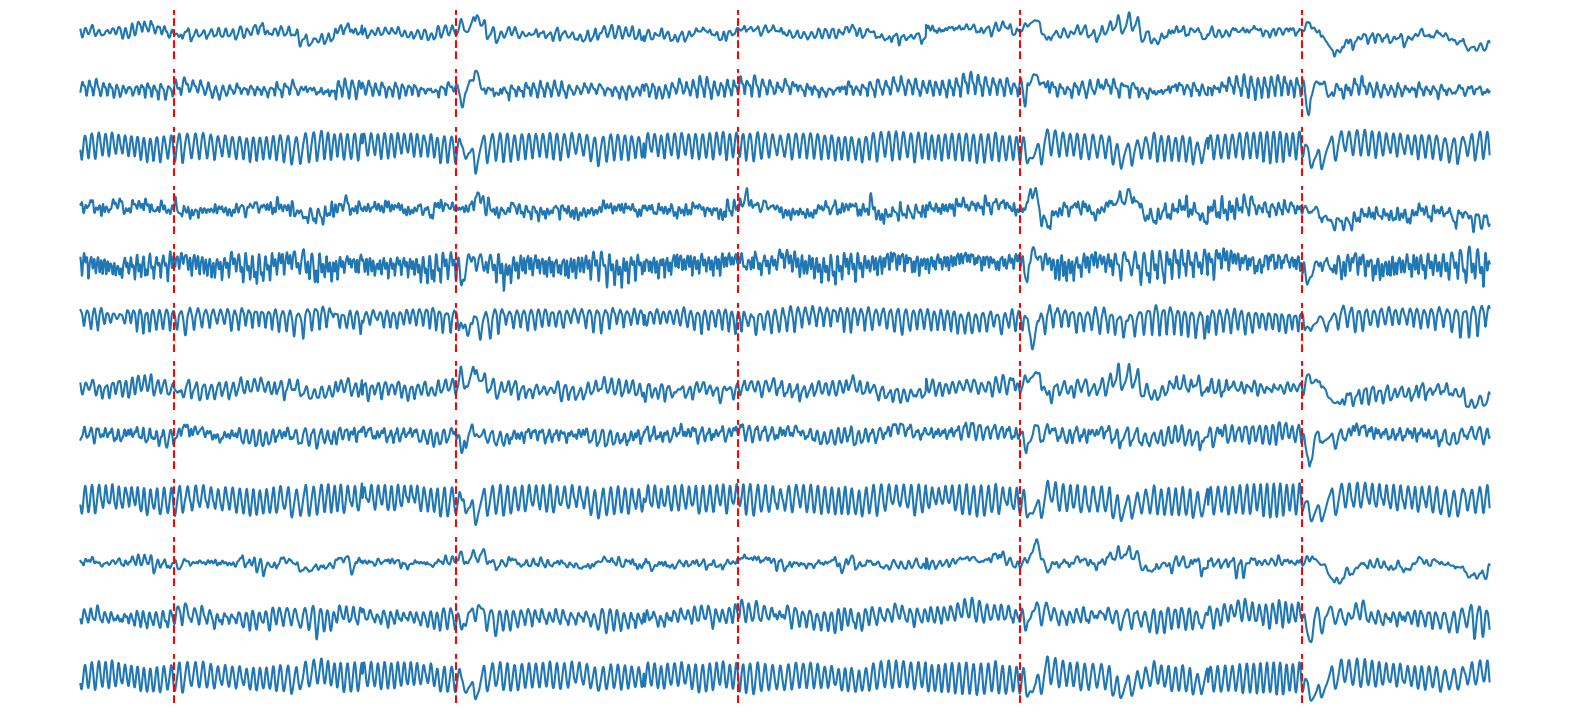

In [46]:
bhv_arr = np.concatenate(df_tr.bhv.values[5:10])[:, :12]

fig, axs = plt.subplots(bhv_arr.shape[-1], 1, sharex='all', figsize=(20, 9))
delay = 0
x_    = np.arange(200, bhv_arr.shape[0], step=600)
for idx, ax in enumerate(axs):
    ax.plot(bhv_arr[:, idx])
    [ax.axvline(x, color='r', linestyle='dashed') for x in x_]
    ax.axis("off")
    # delay += 600


Text(0.5, 0, 'Time (s)')

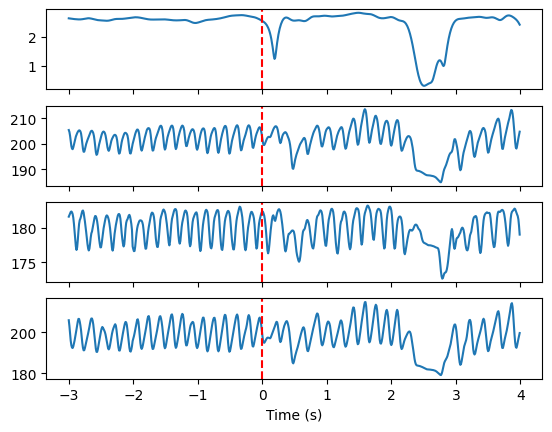

In [52]:
fig, ax = plt.subplots(4, 1, sharex='all')
tr = 190
ax[0].plot(np.arange(-3, 4, step=0.01), df_sorted.power.values[tr][:, 8])
ax[1].plot(np.arange(-3, 4, step=0.01), df_sorted.bhv_concat.values[tr][:, 2])
ax[2].plot(np.arange(-3, 4, step=0.01), df_sorted.bhv_concat.values[tr][:, 5])
ax[3].plot(np.arange(-3, 4, step=0.01), df_sorted.bhv_concat.values[tr][:, 8])
[ax_.axvline(0, color='r', linestyle='dashed') for ax_ in ax]
ax[-1].set_xlabel('Time (s)')


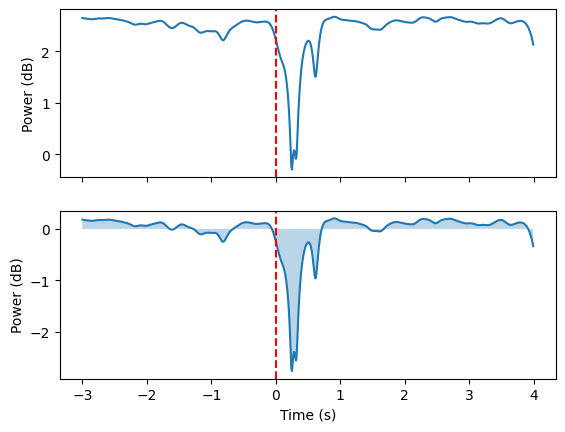

In [88]:
fig, ax = plt.subplots(2, 1, sharex='all')
tr = 75
ax[0].plot(np.arange(-3, 4, step=0.01), df_sorted.power.values[tr][:, 8])
ax[1].plot(np.arange(-3, 4, step=0.01), df_sorted.power.values[tr][:, 8] - df_sorted.power.values[tr][150:300, 8].mean())
[ax_.axvline(0, color='r', linestyle='dashed') for ax_ in ax]
ax[-1].set_xlabel('Time (s)')
ax[0].set_ylabel('Power (dB)')
ax[1].set_ylabel('Power (dB)')
ax[1].fill_between(np.arange(-3, 4, step=0.01), df_sorted.power.values[tr][:, 8] - df_sorted.power.values[tr][150:300, 8].mean(), 0, alpha=0.3)

In [94]:
df_sorted.disturb_score.values[tr].mean()

-0.6366258616028548

(-1.0, 1.0)

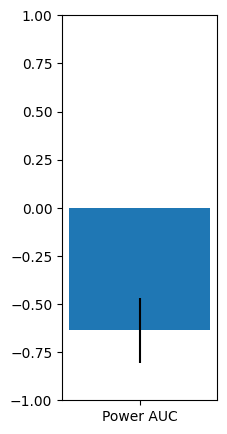

In [100]:
fig, ax = plt.subplots(figsize=(2, 5))
tr = 75
ax.bar('Power AUC', df_sorted.disturb_score.values[tr].mean(), yerr=df_sorted.disturb_score.values[tr].std())
ax.set_ylim(-1, 1)

Text(0.5, 0, 'Disturb score mean')

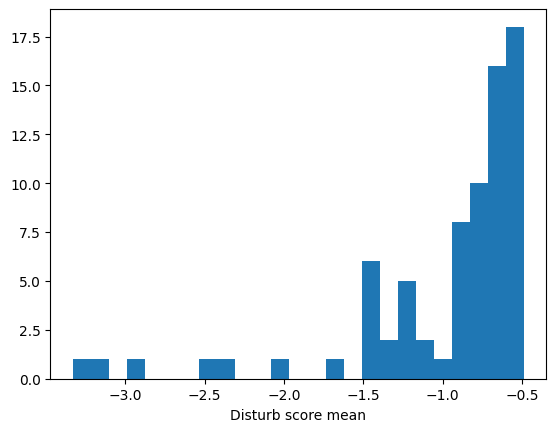

In [53]:
fig, ax = plt.subplots()
ax.hist(df_design.disturb_mean.values, bins=25)
ax.set_xlabel('Disturb score mean')

In [118]:
mean_disturb.shape

(257,)

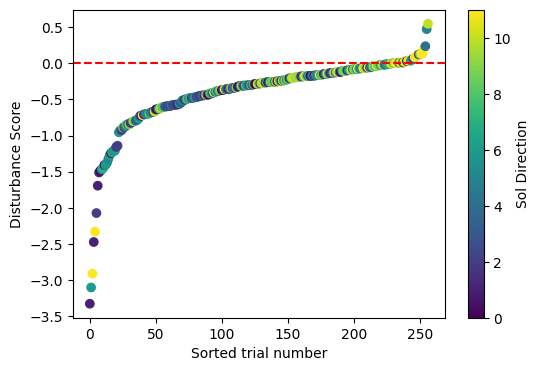

In [54]:
mean_disturb = np.stack(df_sorted.disturb_score.values).mean(-1)
fig, ax = plt.subplots(figsize=(6, 4))
# vizutils.shaded_errorbar(ax, df_sorted.index, mean_disturb)
scatter = ax.scatter(df_sorted.index, mean_disturb, c=df_sorted['values_Sol_direction'], cmap='viridis')
ax.axhline(0, color='r', linestyle='dashed')
ax.set_ylabel('Disturbance Score')
ax.set_xlabel('Sorted trial number')
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('Sol Direction')

In [126]:
df_sorted.columns

Index(['index', 'animal', 'session', 'trial_id', 'trial_name', 'trial_length',
       'bin_size', 'idx_trial_start', 'idx_trial_end', 'idx_CPI',
       ...
       'CP_rates_pca_concat', 'VAL_rates_pca_concat', 'bhv_concat',
       'concat_perturb_time', 'concat_trial_start', 'power', 'phases',
       'disturb_score', 'perturb_phase', '_row_sum'],
      dtype='object', length=101)

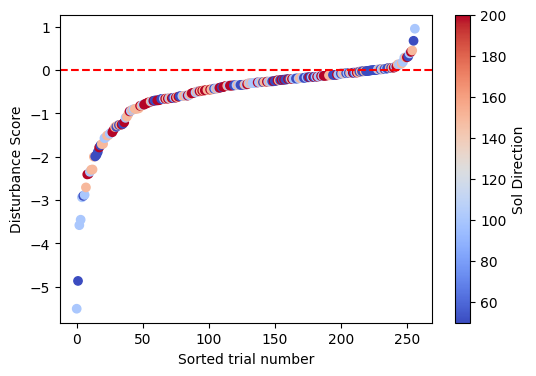

In [125]:
mean_disturb = np.stack(df_sorted.disturb_score.values).mean(-1)
fig, ax = plt.subplots(figsize=(6, 4))
# vizutils.shaded_errorbar(ax, df_sorted.index, mean_disturb)
scatter = ax.scatter(df_sorted.index, mean_disturb, c=df_sorted['values_Sol_duration'], cmap='coolwarm')
ax.axhline(0, color='r', linestyle='dashed')
ax.set_ylabel('Disturbance Score')
ax.set_xlabel('Sorted trial number')
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('Sol Direction')

# Disturbance axis?

In [243]:
df_design_ = df_design.sample(frac=1, random_state=42).reset_index(drop=True)
df_design_.shape

(257, 103)

In [ ]:
# df_design_ = df_design.sample(frac=1, random_state=42).reset_index(drop=True)

X = np.stack(df_design_.MOp_rates_pca_concat.values)
y = df_design_.disturb_sum.values
n_trials, n_time, n_feat = X.shape
cross_val_score(
    Ridge(alpha=100),
    X.reshape(n_trials, -1), 
    y,
    cv=5,
).mean()

0.003906330348226206

In [170]:
X.reshape(n_trials*n_time, -1).shape

(25700, 178)

In [168]:
X = np.stack(df_design_.MOp_rates_pca_concat.values)[:, 250:350, :]
y = np.stack(df_design_.power.values)[:, 250:350, :]
n_trials, n_time, n_feat = X.shape

cross_val_score(
    Ridge(alpha=100),
    X.reshape(n_trials*n_time, -1), 
    y.reshape(n_trials*n_time, -1),
    cv=5,
).mean()

0.5435787796764686

In [277]:
axis_locomotion = subspaces.compute_embedding(
    df_design_,
    'MOp_rates_pca_concat',
    'bhv_concat',
    (300, 400),
    subspaces.ReducedRankCommSubspace(rank=36)
)

axis_disturbance = subspaces.compute_embedding(
    df_design_,
    'MOp_rates_pca_concat',
    'power',
    (300, 400),
    subspaces.ReducedRankCommSubspace(rank=12)
)

overlap = subspaces.compute_overlap_between_subspaces(
    axis_locomotion,
    axis_disturbance,
)
print(overlap)

0.4437578671846577


In [306]:
# axis_locomotion = subspaces.compute_embedding(
#     df_design_,
#     'MOp_rates_pca_concat',
#     'bhv_concat',
#     (400, 500),
#     subspaces.ReducedRankCommSubspace(rank=36)
# )

axis_disturbance = subspaces.compute_embedding(
    df_design_,
    'SSp_rates_pca_concat',
    'power',
    (300, 400),
    subspaces.ReducedRankCommSubspace(rank=12)
)

# overlap = subspaces.compute_overlap_between_subspaces(
#     axis_locomotion,
#     axis_disturbance,
# )
# print(overlap)

In [307]:
axis_disturbance.shape

(69, 12)

In [320]:
targets = df_design_.values_Sol_direction.values.tolist()
scores_full, times = decode.moving_window_decoding(
    np.stack(df_design_[f"CP_rates_pca_concat"])[:, :, :12],
    targets,
    window_length_bin=20,
    step_bin=2,
    cv=5,
)

axis_disturbance = subspaces.compute_embedding(
    df_design_,
    'CP_rates_pca_concat',
    'power',
    (300, 400),
    subspaces.ReducedRankCommSubspace(rank=12)
)
projected_arr = np.array([arr @ axis_disturbance for arr in df_design_[f'CP_rates_pca_concat'].values])

targets = df_design_.values_Sol_direction.values.tolist()
scores_proj, times = decode.moving_window_decoding(
    projected_arr,
    targets,
    window_length_bin=20,
    step_bin=2,
    cv=5,
)

100%|██████████| 341/341 [00:03<00:00, 112.20it/s]


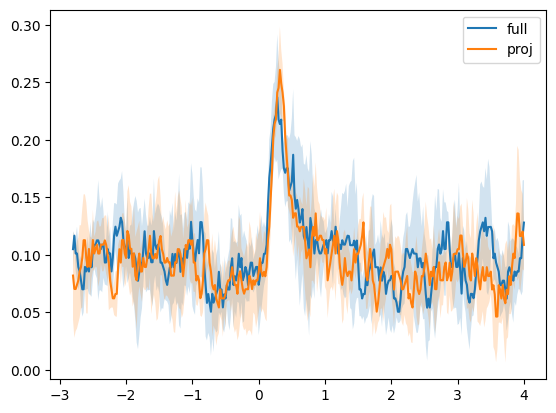

In [321]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, times-3, scores_full, label='full')
vizutils.shaded_errorbar(ax, times-3, scores_proj, label='proj')
ax.legend()


In [287]:
projected_arr = np.array([arr @ axis_disturbance for arr in df_design_[f'VAL_rates_concat'].values])


In [288]:
targets = df_design_.values_Sol_direction.values.tolist()
scores, times = decode.moving_window_decoding(
    projected_arr,
    targets,
    window_length_bin=10,
    step_bin=2,
    cv=5,
)

  0%|          | 0/346 [00:00<?, ?it/s]

100%|██████████| 346/346 [00:02<00:00, 124.66it/s]


(<matplotlib.lines.Line2D at 0x7fd83472deb0>,
 <matplotlib.collections.FillBetweenPolyCollection at 0x7fd83472e5a0>)

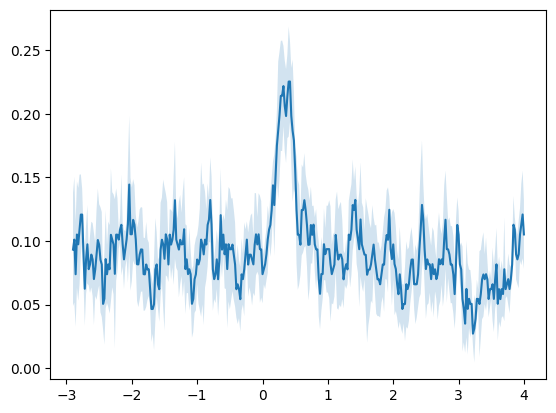

In [289]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, times-3, scores)

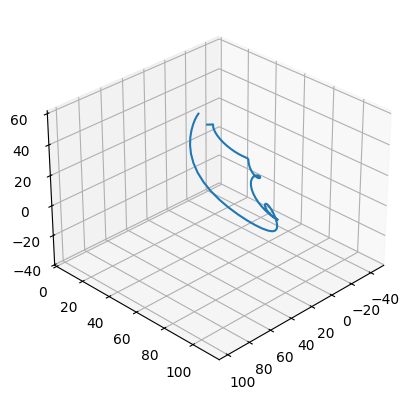

In [297]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    df_design.MOp_rates_pca_concat.values[0][300:400, 0],
    df_design.MOp_rates_pca_concat.values[0][300:400, 1],
    df_design.MOp_rates_pca_concat.values[0][300:400, 2],
    )
ax.view_init(30,   45)   # default-ish perspective

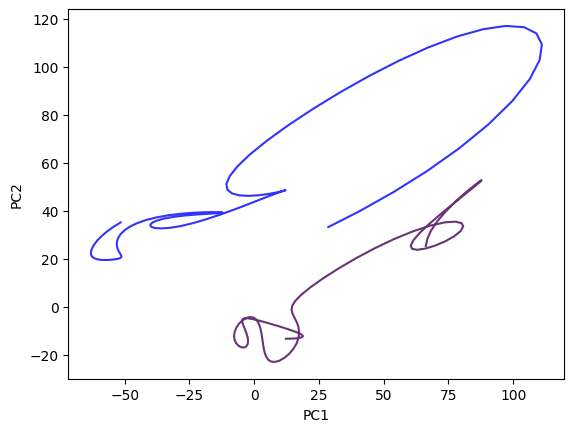

In [340]:

fig, ax = plt.subplots()
# ax = fig.add_subplot(111, projection="3d")

cmap = plt.cm.viridis
n_trials = 1
colors = cmap(np.linspace(0, 1, n_trials))

# for tr, c in zip(range(n_trials), colors):
traj = df_design.MOp_rates_pca_concat.values[175][299:400, :]
ax.plot(
    traj[:, 0],
    traj[:, 1],
    # traj[:, 2],
    color=c,
    alpha=0.8
)
traj = df_design.MOp_rates_pca_concat.values[2][299:400, :]
ax.plot(
    traj[:, 0],
    traj[:, 1],
    # traj[:, 2],
    color='b',
    alpha=0.8
)

# ax.view_init(elev=30, azim=75)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
# ax.set_zlabel("PC3")

plt.show()

# Is there an efference copy

In [ ]:
df_design = df_sorted.copy()
df_design = df_design.iloc[sorted(dstrb_idx[:125])]
df_design['disturb_sum'] = df_design['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))
df_design['disturb_mean'] = df_design['disturb_score'].apply(lambda a: np.mean(a))

df_design_ = df_design.sample(frac=1, random_state=42).reset_index(drop=True)
df_design_.shape

(75, 104)

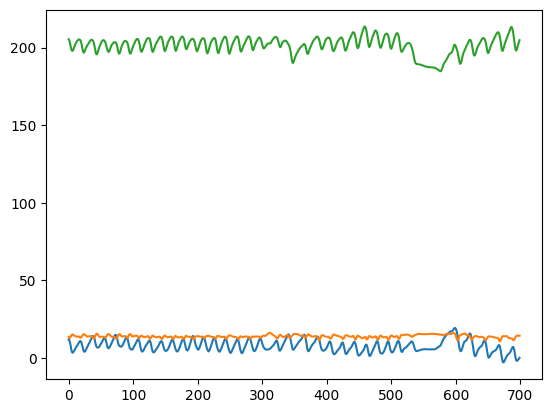

In [90]:
plt.plot(df_design.bhv_concat.values[-10][:, :3])

In [108]:

# bhv_rank = df_trials.bhv.values[0].shape[-1]

overlaps_dict_top_half = {}

min_time_bin=150
max_time_bin=500
window_length_bin = 30
step_bin = 2
time_bins = np.arange(min_time_bin, max_time_bin + 1 - window_length_bin, step=step_bin)
area_a = 'MOp'
area_b = 'SSp'
area_c = 'bhv'

n_comps=10
bhv_rank = 10



# Precompute embeddings for all time bins
embeddings_a = {}
embeddings_b = {}

for t in tqdm(time_bins, desc=f"Computing embeddings {area_a}->{area_c} and {area_a}->{area_b}"):
    embeddings_a[t] = subspaces.compute_embedding(
        df_design_,
        f'{area_a}_rates_pca_concat',
        f'bhv_concat',
        (t, t + window_length_bin),
        subspaces.ReducedRankCommSubspace(rank=bhv_rank),
    )

    embeddings_b[t] = subspaces.compute_embedding(
        df_design_,
        f'{area_a}_rates_pca_concat',
        f'{area_b}_rates_pca_concat',
        (t, t + window_length_bin),
        subspaces.ReducedRankCommSubspace(rank=n_comps),
    )

# Compute overlap matrix
overlaps = []

for t_a in tqdm(time_bins, desc='\tComputing overlaps'):
    embd_a = embeddings_a[t_a]

    overlaps_row = []
    for t_b in time_bins:
        embd_b = embeddings_b[t_b]
        overlap = subspaces.compute_overlap_between_subspaces(
            embd_a, embd_b
        )
        overlaps_row.append(overlap)

    overlaps.append(overlaps_row)

overlaps = np.array(overlaps)

overlaps_dict_top_half[f'{area_a} -> {area_b}'] = np.array(overlaps)


time_points = np.arange(min_time_bin + window_length_bin, max_time_bin + 1, step_bin) * 0.01
time_points = time_points - 3




Computing embeddings MOp->bhv and MOp->SSp:   0%|          | 0/161 [00:00<?, ?it/s]

Computing embeddings MOp->bhv and MOp->SSp:  20%|█▉        | 32/161 [00:12<00:50,  2.56it/s]


KeyboardInterrupt: 

In [ ]:
de

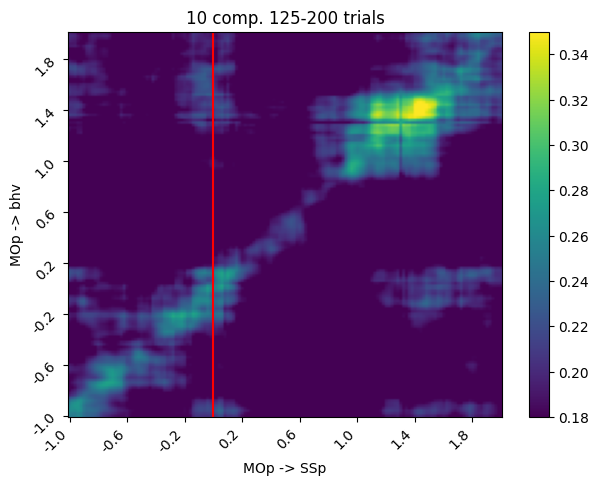

In [92]:
fig, ax = plt.subplots(figsize=(7, 5), sharex='all', sharey='all')
im = ax.imshow(overlaps_dict_top_half[f'{area_a} -> {area_b}'], origin='lower', cmap='viridis', aspect='auto')
cbar = fig.colorbar(im, ax=ax)
im.set_clim(0.18, 0.35)

xticks_pos = np.arange(0, overlaps_dict_top_half[f'{area_a} -> {area_b}'].shape[1], 20)       # positions
xticks_lab = np.round(time_points[xticks_pos], 3)      # labels (custom)

ax.set_xticks(xticks_pos)
ax.set_xticklabels(xticks_lab, rotation=45, ha='right')
ax.axvline(np.where(time_points == 0), color='r')
ax.set_xlabel(f'{area_a} -> {area_b}')

ax.set_yticks(xticks_pos)
ax.set_yticklabels(xticks_lab, rotation=45, ha='right')
# ax.axhline(np.where(time_points == 0), color='r')
ax.set_ylabel(f'{area_a} -> bhv')

# plt.tight_layout()
ax.set_title(f'10 comp. 125-200 trials')
plt.show()

## Refactor embedding function to go faster

In [223]:
df_design = df_sorted.copy()
df_design = df_design.iloc[125:200]
df_design['disturb_sum'] = df_design['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))
df_design['disturb_mean'] = df_design['disturb_score'].apply(lambda a: np.mean(a))

df_design_ = df_design.sample(frac=1, random_state=42).reset_index(drop=True)
df_design_.shape

(75, 104)

In [ ]:
min_time_bin=150
max_time_bin=500
window_length_bin = 50
step_bin = 5
time_bins = np.arange(min_time_bin, max_time_bin + 1 - window_length_bin, step=step_bin)

area_a = 'VAL'
area_b = 'CP'
area_c = 'bhv'

rank=5

embeddings_1 = {}
embeddings_2 = {}
arr_a = np.stack(df_design_[f'{area_a}_rates_pca_concat'].values)
arr_b = np.stack(df_design_[f'{area_b}_rates_pca_concat'].values)
arr_c = np.stack(df_design_[f'bhv_concat'].values)
overlaps_dict = {}
for t in tqdm(time_bins, desc=f"Computing embeddings {area_a}->{area_c} and {area_a}->{area_b}"):
    arr_a_ = arr_a[:, t: t+window_length_bin, :]
    arr_b_ = arr_b[:, t: t+window_length_bin, :]
    arr_c_ = arr_c[:, t: t+window_length_bin, :]
    _, _, feat_a = arr_a_.shape
    _, _, feat_b = arr_b_.shape
    _, _, feat_c = arr_c_.shape



    embeddings_1[t] = subspaces.compute_embedding_on_arr(
        arr_a_.reshape(-1, feat_a),
        arr_b_.reshape(-1, feat_b),
        subspaces.ReducedRankCommSubspace(rank=rank),
    )

    embeddings_2[t] = subspaces.compute_embedding_on_arr(
        arr_a_.reshape(-1, feat_a),
        arr_c_.reshape(-1, feat_c),
        subspaces.ReducedRankCommSubspace(rank=rank),
    )

# Compute overlap matrix
overlaps = []

for t_a in tqdm(time_bins, desc='\tComputing overlaps'):
    embd_a = embeddings_1[t_a]

    overlaps_row = []
    for t_b in time_bins:
        embd_b = embeddings_2[t_b]
        overlap = subspaces.compute_overlap_between_subspaces(
            embd_a, embd_b
        )
        overlaps_row.append(overlap)

    overlaps.append(overlaps_row)

overlaps = np.array(overlaps)
overlaps_dict[f'{area_a} -> {area_b}'] = np.array(overlaps)


time_points = np.arange(min_time_bin + window_length_bin, max_time_bin + 1, step_bin) * 0.01
time_points = time_points - 3

Computing embeddings VAL->bhv and VAL->CP:   0%|          | 0/61 [00:00<?, ?it/s]

	Computing overlaps: 100%|██████████| 61/61 [00:00<00:00, 117.58it/s]


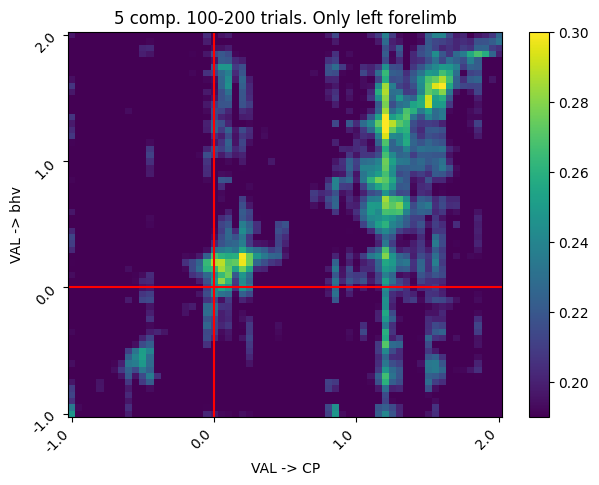

In [242]:
fig, ax = plt.subplots(figsize=(7, 5), sharex='all', sharey='all')
im = ax.imshow(overlaps_dict[f'{area_a} -> {area_b}'], origin='lower', cmap='viridis', aspect='auto')
cbar = fig.colorbar(im, ax=ax)
im.set_clim(0.19, 0.3)

xticks_pos = np.arange(0, overlaps_dict[f'{area_a} -> {area_b}'].shape[1], 20)       # positions
xticks_lab = np.round(time_points[xticks_pos], 3)      # labels (custom)

ax.set_xticks(xticks_pos)
ax.set_xticklabels(xticks_lab, rotation=45, ha='right')
ax.axvline(np.where(time_points == 0), color='r')
ax.set_xlabel(f'{area_a} -> {area_b}')

ax.set_yticks(xticks_pos)
ax.set_yticklabels(xticks_lab, rotation=45, ha='right')
ax.axhline(np.where(time_points == 0), color='r')
ax.set_ylabel(f'{area_a} -> bhv')

# plt.tight_layout()
ax.set_title(f'5 comp. 100-200 trials. Only left forelimb')
plt.show()

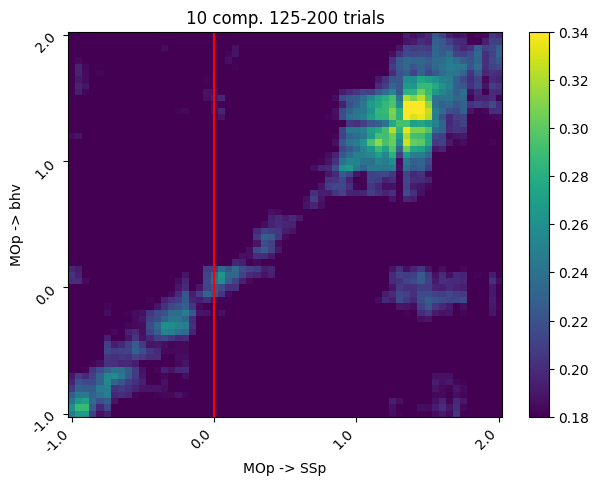

In [145]:
fig, ax = plt.subplots(figsize=(7, 5), sharex='all', sharey='all')
im = ax.imshow(overlaps_dict[f'{area_a} -> {area_b}'], origin='lower', cmap='viridis', aspect='auto')
cbar = fig.colorbar(im, ax=ax)
im.set_clim(0.18, 0.34)

xticks_pos = np.arange(0, overlaps_dict[f'{area_a} -> {area_b}'].shape[1], 20)       # positions
xticks_lab = np.round(time_points[xticks_pos], 3)      # labels (custom)

ax.set_xticks(xticks_pos)
ax.set_xticklabels(xticks_lab, rotation=45, ha='right')
ax.axvline(np.where(time_points == 0), color='r')
ax.set_xlabel(f'{area_a} -> {area_b}')

ax.set_yticks(xticks_pos)
ax.set_yticklabels(xticks_lab, rotation=45, ha='right')
# ax.axhline(np.where(time_points == 0), color='r')
ax.set_ylabel(f'{area_a} -> bhv')

# plt.tight_layout()
ax.set_title(f'10 comp. 125-200 trials')
plt.show()

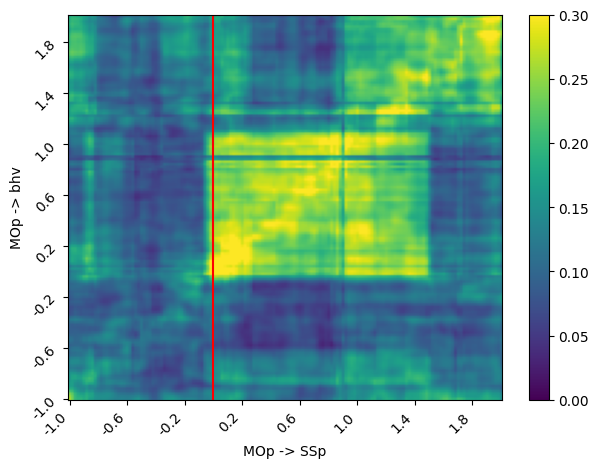

In [25]:
fig, ax = plt.subplots(figsize=(7, 5), sharex='all', sharey='all')
im = ax.imshow(overlaps_dict_top_half[f'{area_a} -> {area_b}'], origin='lower', cmap='viridis', aspect='auto')
cbar = fig.colorbar(im, ax=ax)
im.set_clim(0, 0.3)

xticks_pos = np.arange(0, overlaps_dict_top_half[f'{area_a} -> {area_b}'].shape[1], 20)       # positions
xticks_lab = np.round(time_points[xticks_pos], 3)      # labels (custom)

ax.set_xticks(xticks_pos)
ax.set_xticklabels(xticks_lab, rotation=45, ha='right')
ax.axvline(np.where(time_points == 0), color='r')
ax.set_xlabel(f'{area_a} -> {area_b}')

ax.set_yticks(xticks_pos)
ax.set_yticklabels(xticks_lab, rotation=45, ha='right')
# ax.axhline(np.where(time_points == 0), color='r')
ax.set_ylabel(f'{area_a} -> {area_c}')
# 
# plt.suptitle('Principal angle overlap (200 ms, [20, 10, 20, 40] comp)', y=0.975)
# plt.tight_layout()
plt.show()

In [58]:
def compute_overlap_heatmap(td, area_a, area_b, time_bins, window_length_bin, rank=5):
    
    embeddings_1 = {}
    embeddings_2 = {}
    arr_a = np.stack(td[f'{area_a}_rates_pca_concat'].values)
    arr_b = np.stack(td['power'].values)
    arr_c = np.stack(td[f'bhv_concat'].values)
    for t in tqdm(time_bins, desc=f"Computing embeddings {area_a}->bhv and {area_a}->{area_b}"):
        arr_a_ = arr_a[:, t: t+window_length_bin, :]
        arr_b_ = arr_b[:, t: t+window_length_bin, :]
        arr_c_ = arr_c[:, t: t+window_length_bin, :]
        _, _, feat_a = arr_a_.shape
        _, _, feat_b = arr_b_.shape
        _, _, feat_c = arr_c_.shape



        embeddings_1[t] = subspaces.compute_embedding_on_arr(
            arr_a_.reshape(-1, feat_a),
            arr_b_.reshape(-1, feat_b),
            subspaces.ReducedRankCommSubspace(rank=rank),
        )

        embeddings_2[t] = subspaces.compute_embedding_on_arr(
            arr_a_.reshape(-1, feat_a),
            arr_c_.reshape(-1, feat_c),
            subspaces.ReducedRankCommSubspace(rank=rank),
        )

    # Compute overlap matrix
    overlaps = []

    for t_a in tqdm(time_bins, desc='\tComputing overlaps'):
        embd_a = embeddings_1[t_a]

        overlaps_row = []
        for t_b in time_bins:
            embd_b = embeddings_2[t_b]
            overlap = subspaces.compute_overlap_between_subspaces(
                embd_a, embd_b
            )
            overlaps_row.append(overlap)

        overlaps.append(overlaps_row)

    overlaps = np.array(overlaps)


    time_points = np.arange(min_time_bin + window_length_bin, max_time_bin + 1, step_bin) * 0.01
    time_points = time_points - 3
    return time_points, overlaps

In [59]:
min_time_bin=150
max_time_bin=500
window_length_bin = 50
step_bin = 10
time_bins = np.arange(min_time_bin, max_time_bin + 1 - window_length_bin, step=step_bin)

area_a = 'MOp'
# area_b = 'VAL'

rank=10
overlaps_dict = {}
trial_arr = np.arange(25, 176, step=100)
for tr in trial_arr:

    trials = dstrb_idx[tr:tr+75]
    df_design = df_tr_sliced.iloc[sorted(trials)]

    time_points, overlaps_dict[tr] = compute_overlap_heatmap(df_design, area_a, area_b, time_bins, window_length_bin, rank=10)

	Computing overlaps: 100%|██████████| 31/31 [00:00<00:00, 185.18it/s]


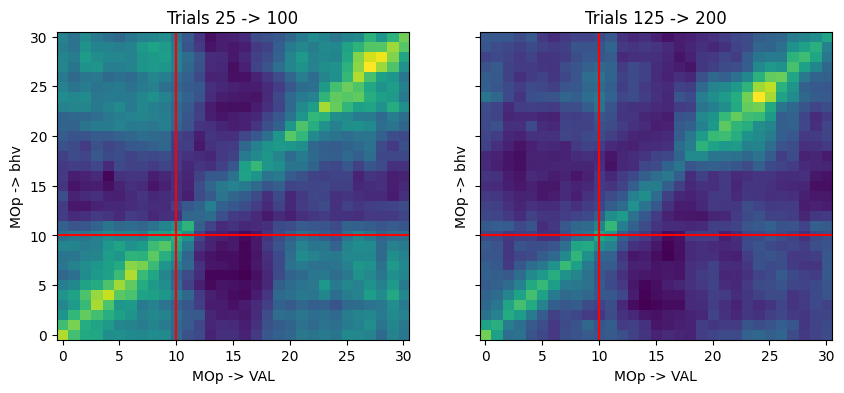

In [63]:
# Calculate the square root of the number of trials and round up to the nearest integer
n_trials = trial_arr.shape[0]
n_cols = int(np.ceil(np.sqrt(n_trials)))
n_rows = int(np.ceil(n_trials / n_cols))

# Create a square-shaped subplot grid
fig, axs = plt.subplots(n_rows, n_cols, sharex='all', sharey='all', figsize=(10, 4))

# Flatten the axis array in case of more than one row and column
for ax, key in zip(axs.flatten(), overlaps_dict.keys()):
    im = ax.imshow(overlaps_dict[key], origin='lower', cmap='viridis', aspect='auto')
    # im.set_clim(0, 0.4)

    
    # xticks_pos = np.arange(0, overlaps.shape[1], 20)       # positions
    # xticks_lab = np.round(time_points[xticks_pos], 3)      # labels (custom)
    
    # ax.set_xticks(xticks_pos)
    # ax.set_xticklabels(xticks_lab, rotation=45, ha='right')
    ax.axvline(np.where(time_points == 0), color='r')
    ax.set_xlabel(f'{area_a} -> {area_b}')

    # ax.set_yticks(xticks_pos)
    # ax.set_yticklabels(xticks_lab, rotation=45, ha='right')
    ax.axhline(np.where(time_points == 0), color='r')
    ax.set_ylabel(f'{area_a} -> bhv')
    ax.set_title(f'Trials {key} -> {key+75}')

# Adjust layout for better spacing
# plt.tight_layout()
plt.show()

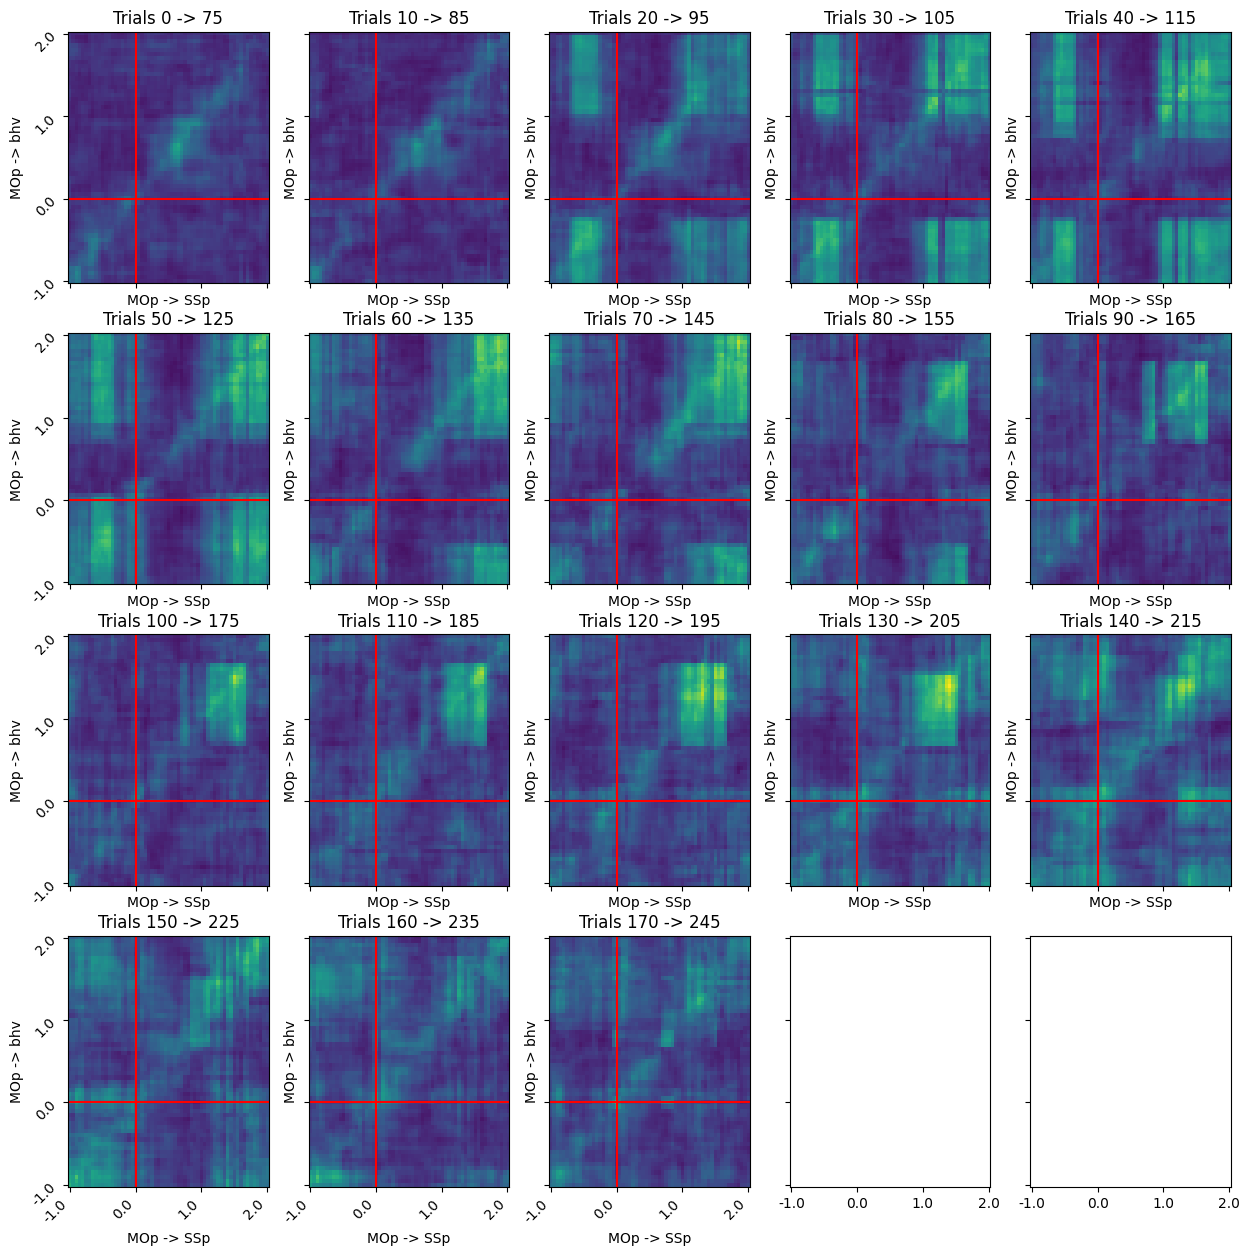

In [ ]:
# Calculate the square root of the number of trials and round up to the nearest integer
n_trials = trial_arr.shape[0]
n_cols = int(np.ceil(np.sqrt(n_trials)))
n_rows = int(np.ceil(n_trials / n_cols))

# Create a square-shaped subplot grid
fig, axs = plt.subplots(n_rows, n_cols, sharex='all', sharey='all', figsize=(15, 15))

# Flatten the axis array in case of more than one row and column
for ax, key in zip(axs.flatten(), overlaps_dict.keys()):
    im = ax.imshow(overlaps_dict[key], origin='lower', cmap='viridis', aspect='auto')
    im.set_clim(0, 0.4)

    
    xticks_pos = np.arange(0, overlaps.shape[1], 20)       # positions
    xticks_lab = np.round(time_points[xticks_pos], 3)      # labels (custom)
    
    ax.set_xticks(xticks_pos)
    ax.set_xticklabels(xticks_lab, rotation=45, ha='right')
    ax.axvline(np.where(time_points == 0), color='r')
    ax.set_xlabel(f'{area_a} -> {area_b}')

    ax.set_yticks(xticks_pos)
    ax.set_yticklabels(xticks_lab, rotation=45, ha='right')
    ax.axhline(np.where(time_points == 0), color='r')
    ax.set_ylabel(f'{area_a} -> bhv')
    ax.set_title(f'Trials {key} -> {key+75}')

# Adjust layout for better spacing
# plt.tight_layout()
plt.show()

# How much variance of each brain region does the disturbance axis explain?

Text(0, 0.5, 'Expl var ratio')

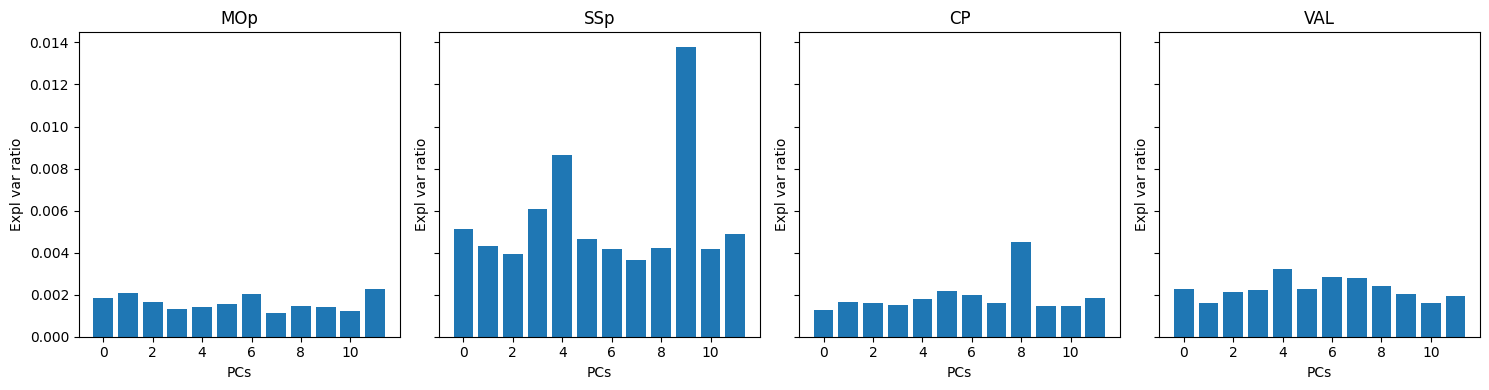

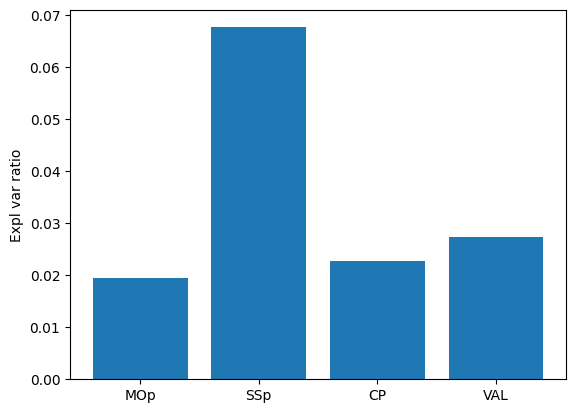

In [378]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4), sharey='all', sharex='all')
areas = ['MOp', 'SSp', 'CP', 'VAL']
time_window = (300, 340)

frac_expl_var = {}
for area, ax in zip(areas, axs):

    arrx = np.stack(df_design_[f'{area}_rates_pca_concat'].values)[:, time_window[0]:time_window[1], :]
    _, _, feats = arrx.shape
    arrx = arrx.reshape(-1, feats)
    arry = np.stack(df_design_.power.values)[:, time_window[0]:time_window[1], :]
    _, _, feats = arry.shape
    arry = arry.reshape(-1, feats)

    axis_disturbance = subspaces.compute_embedding_on_arr(
        arrx, arry, subspaces.ReducedRankCommSubspace(12)
    )
    total_var = np.sum(np.var(arrx, axis=0))
    disturb_var = subspaces.variance_in_dims(arrx, axis_disturbance)
    disturb_var_ratio = disturb_var / total_var
    # variance / np.sum(np.var(arrx[:, :12], axis=0))

    # ax.bar(range(12), np.var(arrx[:, :12], axis=0) / total_var, label='full')
    ax.bar(range(12), disturb_var_ratio)
    ax.set_xlabel('PCs')
    ax.set_ylabel('Expl var ratio')
    ax.set_title(area)

    frac_expl_var[area] = np.sum(disturb_var_ratio)

plt.tight_layout()

fig, ax = plt.subplots()
ax.bar(frac_expl_var.keys(), frac_expl_var.values())
ax.set_ylabel('Expl var ratio')
# for

In [496]:
df_design = df_sorted.copy()
df_design = df_design.iloc[:]
df_design['disturb_sum'] = df_design['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))
df_design['disturb_mean'] = df_design['disturb_score'].apply(lambda a: np.mean(a))

df_design_ = df_design.sample(frac=1, random_state=42).reset_index(drop=True)
df_design_.shape

(261, 104)

In [448]:
area = 'VAL'
X = np.stack(df_sorted[f'{area}_rates_pca_concat'].values)[:, :, :12]
_, _, feats = X.shape
X = X.reshape(-1, feats)

y = np.stack(df_sorted[f'MOp_rates_pca_concat'].values)
_, _, feats = y.shape
y = y.reshape(-1, feats)

r2s = cross_val_score(
    Ridge(0.01),
    X,
    np.roll(y, 0),  # 1, predicts past, -1 predicts future
    cv=5,
    scoring=decode.get_custom_scorer()
)

print(r2s.mean(), r2s.std())

0.10156113261346318 0.01315122529035724


In [455]:
area = 'VAL'
axis_disturbance = subspaces.compute_embedding(
    df_design_,
    f'{area}_rates_pca_concat',
    'power',
    (300, 700),
    subspaces.ReducedRankCommSubspace(rank=12)
)

projected_arr = np.array([arr @ axis_disturbance for arr in df_sorted[f'{area}_rates_pca_concat'].values])
_, _, feats = projected_arr.shape
projected_arr = projected_arr.reshape(-1, feats)

y = np.stack(df_sorted[f'MOp_rates_pca_concat'].values)
_, _, feats = y.shape
y = y.reshape(-1, feats)

r2s = cross_val_score(
    Ridge(0.01),
    projected_arr,
    np.roll(y, 4),  # 1, predicts past, -1 predicts future
    cv=5,
    scoring=decode.get_custom_scorer()
)

print(r2s.mean(), r2s.std())

0.07399359649191475 0.011890086016632044


In [489]:
area = 'SSp'
axis_disturbance = subspaces.compute_embedding(
    df_sorted,
    f'{area}_rates_pca_concat',
    'power',
    (0, 200),
    subspaces.ReducedRankCommSubspace(rank=12)
)

projected_arr = np.array([arr @ axis_disturbance for arr in df_sorted[f'{area}_rates_pca_concat'].values])


In [492]:
scores_full, times = decode.decoding_moving_window(
    Ridge(0.01),
    np.stack(df_sorted[f'SSp_rates_pca_concat'].values)[:, :, :12],
    np.stack(df_sorted[f'MOp_rates_pca_concat'].values),
    step_bin=10
)

scores_proj, times = decode.decoding_moving_window(
    Ridge(0.01),
    projected_arr,
    np.stack(df_sorted[f'MOp_rates_pca_concat'].values),
    step_bin=10
)

100%|██████████| 69/69 [00:11<00:00,  6.00it/s]


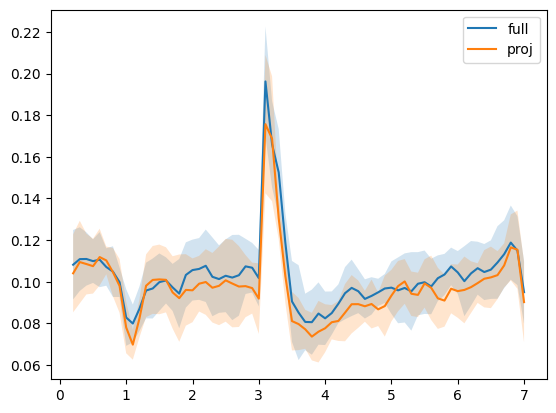

In [493]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, times, scores_full, label='full')
vizutils.shaded_errorbar(ax, times, scores_proj, label='proj')
ax.legend()

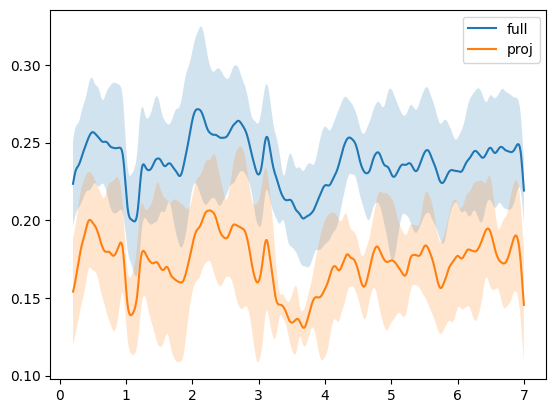

In [487]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, times, scores_full, label='full')
vizutils.shaded_errorbar(ax, times, scores_proj, label='proj')
ax.legend()

In [ ]:
# df_design = df_sorted.copy()
# df_design = df_design.iloc[:]
# df_design['disturb_sum'] = df_design['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))
# df_design['disturb_mean'] = df_design['disturb_score'].apply(lambda a: np.mean(a))

df_sorted_ = df_sorted.sample(frac=1, random_state=42).reset_index(drop=True)

In [537]:
# perturb_td = pyal.restrict_to_interval(df_tr, start_point_name='idx_sol_on', rel_start=-200, rel_end=200)
# scores_ssp_mop, times = decode.decoding_moving_window(
#     Ridge(0.01),
#     np.stack(df_tr_sliced[f'SSp_rates_pca_concat'].values),
#     np.stack(df_tr_sliced[f'MOp_rates_pca_concat'].values),
#     step_bin=5
# )

scores_mop_ssp, times = decode.decoding_moving_window(
    Ridge(100),
    np.stack(df_sorted_[f'MOp_rates_pca_concat'].values),
    np.stack(df_sorted_[f'SSp_rates_pca_concat'].values),
    step_bin=10
)

100%|██████████| 69/69 [00:47<00:00,  1.45it/s]


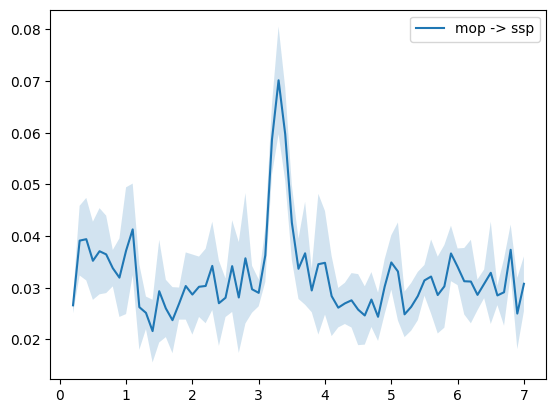

In [536]:
fig, ax = plt.subplots()
# vizutils.shaded_errorbar(ax, times, scores_ssp_mop, label='ssp -> mop')
vizutils.shaded_errorbar(ax, times, scores_mop_ssp, label='mop -> ssp')
ax.legend()

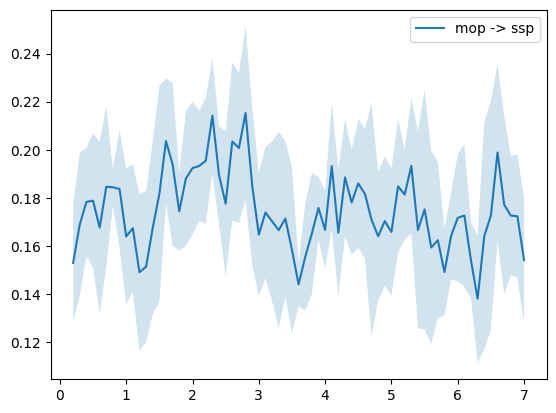

In [538]:
fig, ax = plt.subplots()
# vizutils.shaded_errorbar(ax, times, scores_ssp_mop, label='ssp -> mop')
vizutils.shaded_errorbar(ax, times, scores_mop_ssp, label='mop -> ssp')
ax.legend()

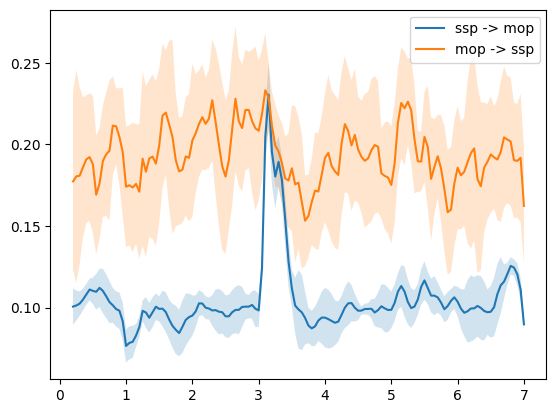

In [498]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, times, scores_ssp_mop, label='ssp -> mop')
vizutils.shaded_errorbar(ax, times, scores_mop_ssp, label='mop -> ssp')
ax.legend()

# Test VAF on disturbance axis

In [61]:
df__.MOp_rates.values[0].shape

(60000, 178)

In [19]:
k = df_.SSp_rates.values[0].shape[1]
k = 50

bootstrapped_fracs = []
n_iter = 20
df__ = df_.copy()
df = dt.add_bhv(df__, bhv_fields=ALL_BHV_FIELDS)

# Compute metric
df = dt.concat_previous_intertrial_signal(df, 'bhv', features=feature_dims)
df = dt.add_concat_perturb_time(df)
df = dt.add_concat_trial_start(df)
df = kin.compute_power_in_bhv_concat_td(df)
df = kin.add_power_metric_to_td(df)

for i in tqdm(range(n_iter)):
    

    for area in ['MOp', 'CP', 'VAL', 'SSp']:
        total_neurons = df[f'{area}_rates'].values[0].shape[1]
        rand_neurons = np.random.randint(0, total_neurons, k)
        df[f'{area}_rates'] = df[f'{area}_rates'].apply(lambda r: r[:, rand_neurons])
        # print(f'{area} shape = {df__[f'{area}_rates'].values[0].shape[1]}')


    df = dt.add_pca_df(df)
    df = dt.concat_previous_intertrial_signal(df, 'MOp_rates_pca')
    df = dt.concat_previous_intertrial_signal(df, 'SSp_rates_pca')
    df = dt.concat_previous_intertrial_signal(df, 'CP_rates_pca')
    df = dt.concat_previous_intertrial_signal(df, 'VAL_rates_pca')


    # Select trials and drop nans
    df_tr = pyal.select_trials(df, df.trial_name == 'trial')
    # df_tr = kin.drop_immobile_trials_from_td(df_tr, p=2, win=10)
    mask = df_tr["disturb_score"].apply(
        lambda x: not np.any(np.isnan(x))
    )
    df_tr = df_tr.loc[mask]

    # Slice fields
    df_tr_sliced = df_tr.copy()
    fields = [
        'power',
        # 'phases', 
        'MOp_rates_pca_concat',
        'SSp_rates_pca_concat',
        'VAL_rates_pca_concat',
        'CP_rates_pca_concat',
        # 'bhv_concat'
        ]
    for field in fields:
        df_tr_sliced[field] = df_tr.apply(
            lambda row: row[field][row["concat_perturb_time"] - 300:row["concat_perturb_time"] + 400, :],
            axis=1
        )


    disturbances = np.sum(np.stack(df_tr_sliced.disturb_score.values), axis=1)
    dstrb_idx = np.argsort(disturbances)

    time_window = (300, 500)

    frac_expl_var = {}
    for area in ['MOp', 'SSp', 'CP', 'VAL']:

        arrx = np.stack(df_tr_sliced[f'{area}_rates_pca_concat'].values)[:, time_window[0]:time_window[1], :]
        _, _, feats = arrx.shape
        arrx = arrx.reshape(-1, feats)
        arry = np.stack(df_tr_sliced.power.values)[:, time_window[0]:time_window[1], :]
        _, _, feats = arry.shape
        arry = arry.reshape(-1, feats)

        axis_disturbance = subspaces.compute_embedding_on_arr(
            arrx, arry, subspaces.ReducedRankCommSubspace(12)
        )
        total_var = np.sum(np.var(arrx, axis=0))
        disturb_var = subspaces.variance_in_dims(arrx, axis_disturbance)
        disturb_var_ratio = disturb_var / total_var


        frac_expl_var[area] = np.sum(disturb_var_ratio)
    bootstrapped_fracs.append(frac_expl_var)



Skipped 71 trials 10.61


100%|██████████| 20/20 [01:42<00:00,  5.11s/it]


In [20]:
bootstrapped_fracs

[{'MOp': 0.15763001630755505,
  'SSp': 0.11238361001354595,
  'CP': 0.18442026762405478,
  'VAL': 0.13324653428241426},
 {'MOp': 0.17403083168608172,
  'SSp': 0.08627633425724626,
  'CP': 0.3351073647604763,
  'VAL': 6.07864055974414e-13},
 {'MOp': 0.23953008704772336,
  'SSp': 1.825502707960471e-11,
  'CP': 0.40577815634073283,
  'VAL': 2.0097547883743836e-12},
 {'MOp': 0.39829002722615314,
  'SSp': 0.11423253553643052,
  'CP': 0.4810307519859363,
  'VAL': 0.31479573256678517},
 {'MOp': 0.5074528827634487,
  'SSp': 0.04398772467830603,
  'CP': 0.357402380969342,
  'VAL': 4.841884977051274e-11},
 {'MOp': 0.648418514078948,
  'SSp': 3.1680414265146977e-12,
  'CP': 0.7364903021088363,
  'VAL': 7.151745442281436e-13},
 {'MOp': 0.2871618910729767,
  'SSp': 1.4162707727247893e-12,
  'CP': 0.9182348376512138,
  'VAL': 2.7656875672707417e-10},
 {'MOp': 0.41106265276744347,
  'SSp': 2.6370137245323223e-12,
  'CP': 0.25863751161000725,
  'VAL': 0.08833601608615343},
 {'MOp': 1.000027563075375,


In [59]:
res = {key: np.array([d[key] for d in bootstrapped_fracs]) for key in bootstrapped_fracs[0].keys()}
res

{'MOp': array([1.31602329e-01, 4.48819663e-02, 2.55803746e-02, 2.22185327e-01,
        1.57609268e-01, 3.44927780e-01, 3.42662738e-01, 2.61261106e-01,
        1.36690702e-12, 1.23093779e-10, 2.50360573e-01, 8.95052879e-02,
        2.70919729e-12, 9.05029651e-13, 8.65011994e-02, 1.46335141e-11,
        2.11692450e-11, 2.50525361e-09, 6.60960975e-02, 2.56905865e-01]),
 'SSp': array([1.50266017e-01, 4.93216313e-02, 1.00530157e-11, 2.31503487e-12,
        1.34964538e-12, 1.18466553e-12, 1.00854885e-12, 1.46882996e-12,
        4.50097238e-13, 2.07054071e-12, 9.95630888e-13, 8.41993394e-13,
        4.30652129e-12, 8.32928322e-13, 1.48362002e-12, 4.90827111e-12,
        6.88428798e-12, 4.75988702e-13, 2.99558168e-12, 2.32434609e-12]),
 'CP': array([1.33203868e-01, 2.17086195e-01, 1.84109478e-01, 4.61808825e-01,
        2.50276788e-01, 2.52033021e-01, 4.04800015e-01, 5.42753871e-01,
        8.85454658e-01, 7.92131987e-01, 1.00002657e+00, 6.94530850e-01,
        4.90688181e-01, 8.89550703e-01, 

In [51]:
res

{'MOp': array([0.13658244, 0.2250869 , 0.23053439, 0.26824527, 0.25854204]),
 'SSp': array([0.1148212 , 0.16157245, 0.3556625 , 0.15185157, 0.27903795]),
 'CP': array([0.19497592, 0.17097732, 0.16640188, 0.25902912, 0.24880954]),
 'VAL': array([1.12034556e-01, 1.11062033e-12, 1.51275659e-12, 1.68180748e-13,
        1.92657294e-12])}

Text(0.5, 1.0, 'Bootstrapped to 50 components')

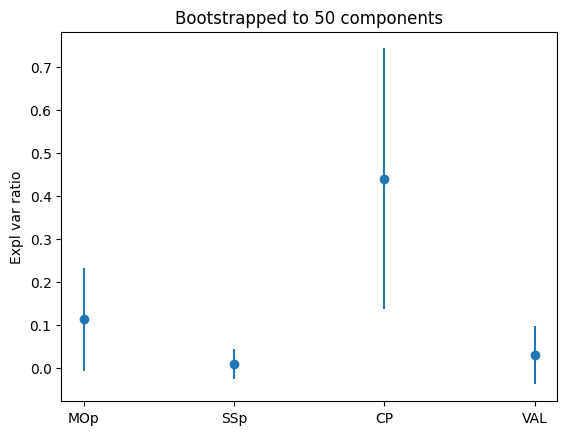

In [62]:
fig, ax = plt.subplots()
ax.errorbar(res.keys(), [val.mean() for val in res.values()], fmt='o', yerr=[val.std() for val in res.values()])
ax.set_ylabel('Expl var ratio')
ax.set_title('Bootstrapped to 50 components')

# How well can you decode the disturbance from the comm subspaces

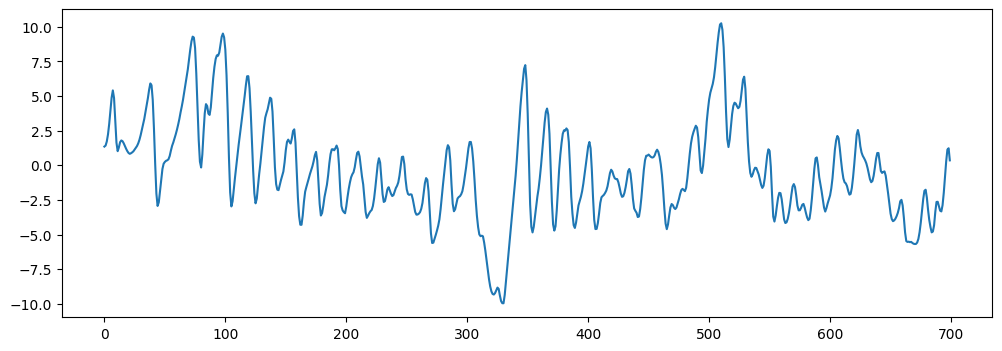

In [39]:
plt.figure(figsize=(12, 4))
plt.plot(df_design.bhv_concat.values[-1][:,0])

In [35]:
idx = sorted(dstrb_idx[80:180])
df_design = df_tr_sliced.copy()
df_design = df_design.iloc[idx]
df_design['disturb_sum'] = df_design['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))
df_design['disturb_mean'] = df_design['disturb_score'].apply(lambda a: np.mean(a))

df_design_ = df_design.sample(frac=1, random_state=42).reset_index(drop=True)

In [25]:
areas = ['MOp', 'CP', 'SSp', 'VAL']
res = {}
for area_a in areas:
    res[area_a] = {}
    for area_b in areas:
        if area_a != area_b:
            emb = subspaces.compute_embedding(
                df_design,
                f'{area_a}_rates_pca_concat',
                f'{area_b}_rates_pca_concat',
                (0, 700),
                subspaces.ReducedRankCommSubspace(rank=50)
            )
            arr = np.array([arr_ @ emb for arr_ in df_design[f'{area_a}_rates_pca_concat'].values])[:, 300:, :]
        else:
            arr = np.stack(df_design[f'{area_a}_rates_pca_concat'])[:, 300:, :]
        n_trials, _, _ = arr.shape
        r2s = cross_val_score(
            Ridge(100),
            arr.reshape(n_trials, -1),
            df_design.disturb_sum.values,
            cv=5,
            # scoring=decode.get_custom_scorer()
        )
        res[area_a][area_b] = r2s
        print(f'{area_a} -> {area_b} r2 mean: {r2s.mean():.3f}, r2 std: {r2s.std():.3f}')


MOp -> MOp r2 mean: -0.044, r2 std: 0.271
MOp -> CP r2 mean: -0.166, r2 std: 0.423
MOp -> SSp r2 mean: -0.091, r2 std: 0.500
MOp -> VAL r2 mean: -0.169, r2 std: 0.398
CP -> MOp r2 mean: -0.066, r2 std: 0.475
CP -> CP r2 mean: -0.044, r2 std: 0.214
CP -> SSp r2 mean: -0.068, r2 std: 0.361
CP -> VAL r2 mean: 0.032, r2 std: 0.363
SSp -> MOp r2 mean: -0.330, r2 std: 0.407
SSp -> CP r2 mean: -0.173, r2 std: 0.275
SSp -> SSp r2 mean: -0.247, r2 std: 0.309
SSp -> VAL r2 mean: -0.245, r2 std: 0.305
VAL -> MOp r2 mean: -0.214, r2 std: 0.435
VAL -> CP r2 mean: -0.102, r2 std: 0.382
VAL -> SSp r2 mean: -0.227, r2 std: 0.349
VAL -> VAL r2 mean: -0.082, r2 std: 0.221


In [137]:
cp_data = {area: res[area]['CP'] / res[area][area].mean() for area in res}

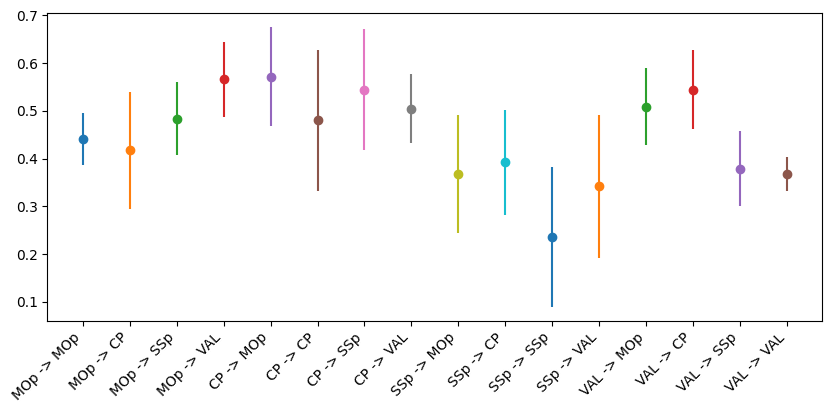

In [18]:
# plot into areas
fig, ax = plt.subplots(figsize=(10, 4))
for area in res.keys():
    for area_ in res.keys():
        ax.errorbar(f'{area} -> {area_}', res[area][area_].mean(), fmt='o', yerr=res[area][area_].std())
plt.xticks(rotation=45, ha='right')
plt.show()

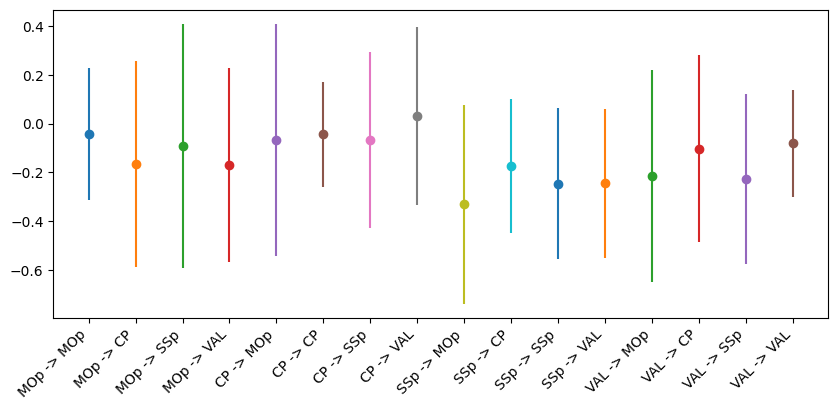

In [26]:
# plot into areas
fig, ax = plt.subplots(figsize=(10, 4))
for area in res.keys():
    for area_ in res.keys():
        ax.errorbar(f'{area} -> {area_}', res[area][area_].mean(), fmt='o', yerr=res[area][area_].std())
plt.xticks(rotation=45, ha='right')
plt.show()

In [98]:
labels = list(res.keys())
values = np.array([[res[row][col] for col in labels] for row in labels])
values

array([[0.37764406, 0.2593887 , 0.23680725, 0.19798699],
       [0.29656353, 0.31303423, 0.16075134, 0.21021589],
       [0.1100607 , 0.16901192, 0.1707391 , 0.03835817],
       [0.110856  , 0.24403392, 0.08062552, 0.30129403]])

In [92]:
normalized_matrix = values / np.diag(values)
normalized_matrix

array([[1.        , 0.82862728, 1.38695386, 0.6571222 ],
       [0.78529907, 1.        , 0.94150279, 0.6977101 ],
       [0.2914403 , 0.53991516, 1.        , 0.12731142],
       [0.29354626, 0.77957583, 0.47221476, 1.        ]])

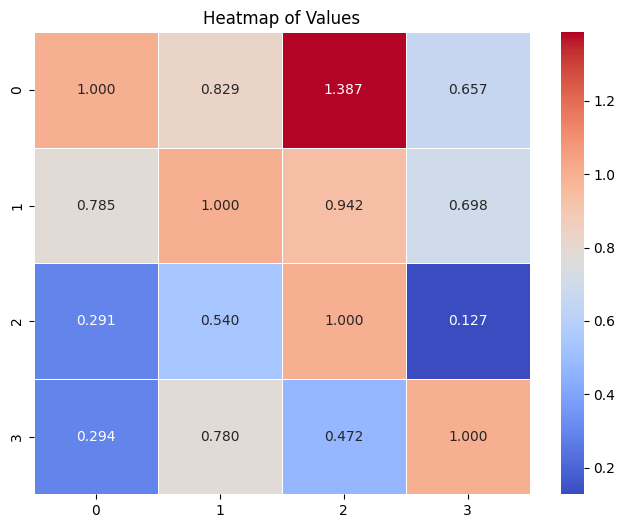

In [101]:
df = pd.DataFrame(normalized_matrix)

# Plotting the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df, annot=True, cmap="coolwarm", fmt=".3f", linewidths=0.5)

# Display the plot
plt.title("Heatmap of Values")
plt.show()

In [116]:
df = pd.DataFrame(res)

# Plotting the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.T, annot=True, cmap="viridis", fmt=".3f", linewidths=0.5)

# Display the plot
plt.title("Heatmap of Values")
plt.show()

ValueError: setting an array element with a sequence.

<Figure size 800x600 with 0 Axes>

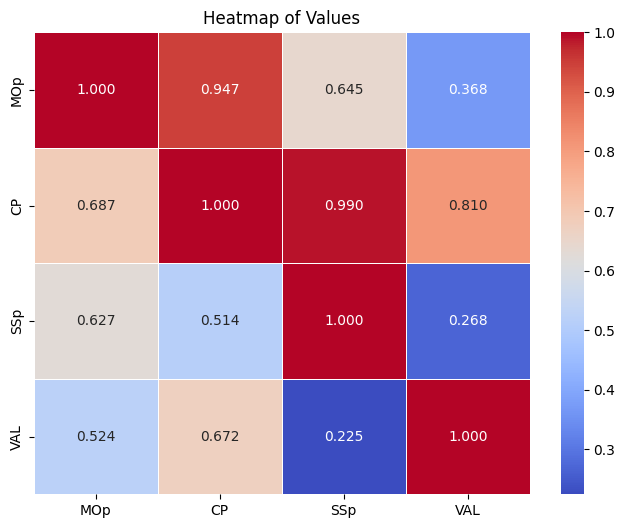

In [89]:
df = pd.DataFrame(normalized_data)

# Plotting the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df, annot=True, cmap="coolwarm", fmt=".3f", linewidths=0.5)

# Display the plot
plt.title("Heatmap of Values")
plt.show()

# Import var in disturb scores

In [4]:
# results_path = "/home/me24/repos/earthquake-analysis/results/rrr/"
with open("bootstrapped_fracs.pkl", "rb") as f:
    vars = pickle.load(f)

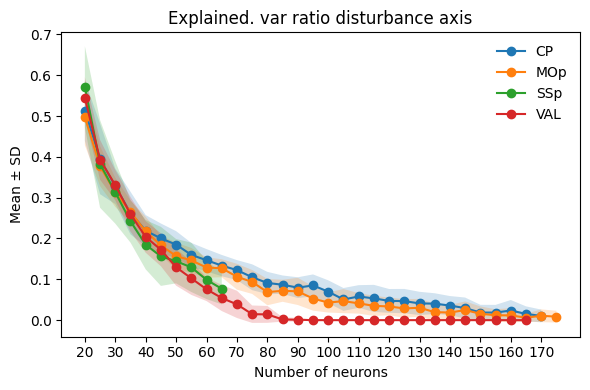

In [11]:
ax = plot_shaded_errorbars(vars)
ax.set_xticks(np.arange(20, 180, step=10))
ax.set_title('Explained. var ratio disturbance axis')
plt.tight_layout()
plt.show()

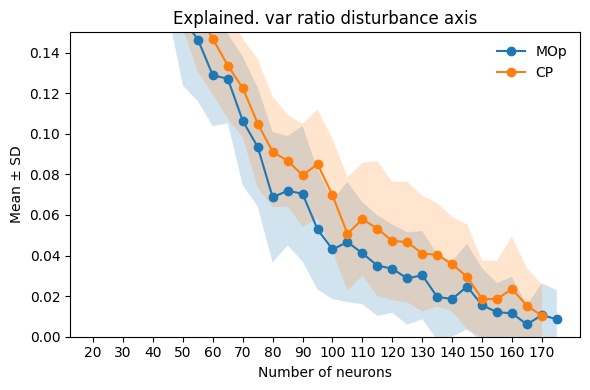

In [12]:
ax = plot_shaded_errorbars(vars, areas=['MOp', 'CP'])
ax.set_xticks(np.arange(20, 180, step=10))
ax.set_title('Explained. var ratio disturbance axis')
ax.set_ylim([0, 0.15])

plt.tight_layout()
plt.show()

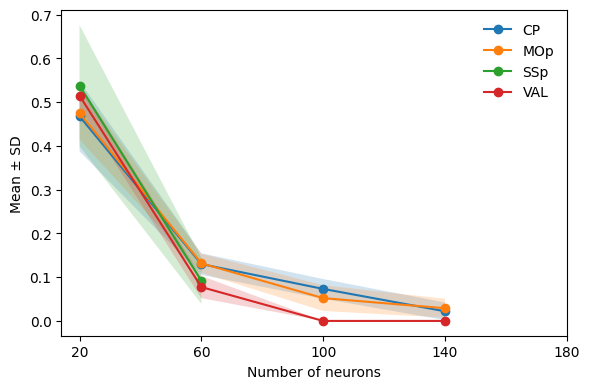

In [39]:
ax = plot_shaded_errorbars(vars)
plt.tight_layout()
plt.show()

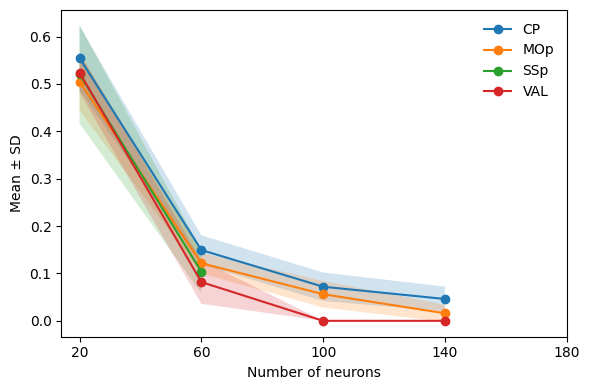

In [37]:
ax = plot_shaded_errorbars(vars)
plt.tight_layout()
plt.show()

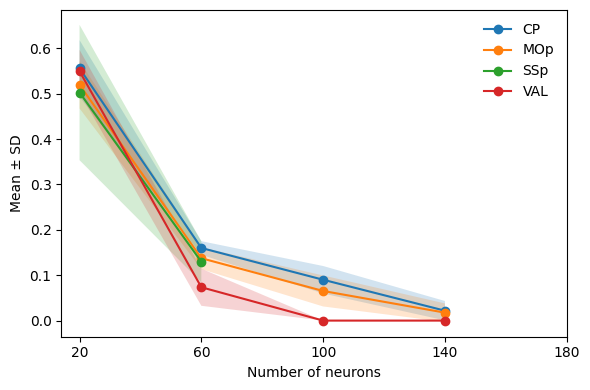

In [35]:
ax = plot_shaded_errorbars(vars)
plt.tight_layout()
plt.show()

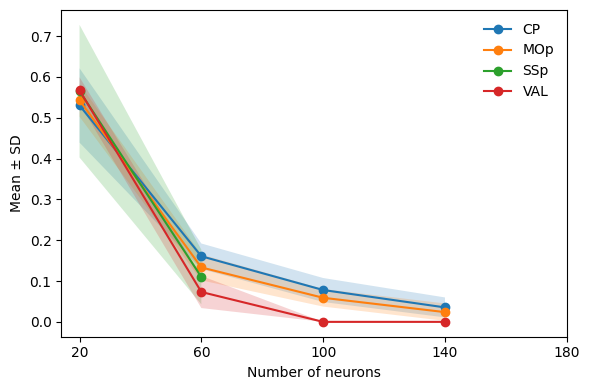

In [33]:
ax = plot_shaded_errorbars(vars)
plt.tight_layout()
plt.show()

In [3]:
def plot_shaded_errorbars(res, areas=None, ax=None, alpha=0.2, marker="o"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    n_neurons = np.array(sorted(res.keys()))
    if areas is None:
        # union of all areas present
        areas = sorted({a for d in res.values() for a in d.keys()})

    for area in areas:
        means = []
        stds = []
        xs = []
        for n in n_neurons:
            vals = res[n].get(area, [])
            if vals is None or len(vals) == 0:
                continue  # skip missing (e.g., SSp at 90)
            v = np.asarray(vals, dtype=float)
            xs.append(n)
            means.append(v.mean())
            stds.append(v.std(ddof=1) if v.size > 1 else 0.0)

        if len(xs) == 0:
            continue

        xs = np.asarray(xs)
        means = np.asarray(means)
        stds = np.asarray(stds)

        ax.plot(xs, means, marker=marker, label=area)
        ax.fill_between(xs, means - stds, means + stds, alpha=alpha)

    ax.set_xlabel("Number of neurons")
    ax.set_ylabel("Mean ± SD")
    ax.set_xticks(n_neurons)
    ax.legend(frameon=False)
    return ax

In [7]:
import os
from joblib import parallel_backend
import joblib

print("os.cpu_count():", os.cpu_count())
print("joblib cpu_count:", joblib.cpu_count())
print("OMP_NUM_THREADS:", os.environ.get("OMP_NUM_THREADS"))
print("MKL_NUM_THREADS:", os.environ.get("MKL_NUM_THREADS"))

os.cpu_count(): 24
joblib cpu_count: 24
OMP_NUM_THREADS: None
MKL_NUM_THREADS: None


# Do some comms spaces predict future or past info?

In [52]:
df_design = df_tr_sliced.copy()
df_design = df_design.iloc[50:150]
df_design['disturb_score'] = df_design['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))
df_design_ = df_design.sample(frac=1, random_state=42).reset_index(drop=True)

In [82]:
emb = subspaces.compute_embedding(
    df_design,
    f'VAL_rates_pca_concat',
    f'MOp_rates_pca_concat',
    (0, 700),
    subspaces.ReducedRankCommSubspace(rank=10)
)
arr_x = np.array([arr_ @ emb for arr_ in df_design[f'VAL_rates_pca_concat'].values])[:, 350:400, :]
arr_y = np.stack(df_design.power.values)[:, 350:400, :]

n_trials, n_time, n_feats = arr_x.shape
r2s = cross_val_score(
    Ridge(100),
    arr_x.reshape(n_trials * n_time, -1),
    np.roll(arr_y.reshape(n_trials * n_time, -1), axis=0, shift=-2),
    cv=5,
    # scoring=decode.get_custom_scorer()
)
print(f'VAL -> MOp r2 mean: {r2s.mean():.4f}, r2 std: {r2s.std():.4f}')


VAL -> MOp r2 mean: 0.1579, r2 std: 0.2658
